## EDA(Exploratory Data Analysis)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("C:\Users\Vishnu\Desktop\resource_demand_forecasting\Resource-Demand-Forecasting\Dataset\Data_Vishnu.csv")
display(df.head())

,ds,unique_id,y
0,01-01-2023,SMU-2_SL-1_Sector-11_OFFSHORE_FPP_Old - New_3 ...,1
1,01-01-2023,SMU-1_SL-4_Sector-10_OFFSHORE_FPP_NEW - NEW_2 ...,1
2,01-01-2023,SMU-1_SL-4_Sector-10_OFFSHORE_FPP_NEW - NEW_3 ...,1
3,01-01-2023,SMU-4_SL-4_Sector-08_OFFSHORE_FPP_Old - New_3 ...,1
4,01-01-2023,SMU-1_SL-4_Sector-10_ONSITE_FPP_NEW - NEW_3 st...,1


In [3]:
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)

num_smu = df['SMU'].nunique()
num_sectors = df['Sector'].nunique()
num_service_lines = df['SL'].nunique()

print(f"Number of unique SMUs: {num_smu}")
print(f"Number of unique Sectors: {num_sectors}")
print(f"Number of unique Service Lines: {num_service_lines}")

Number of unique SMUs: 4
Number of unique Sectors: 20
Number of unique Service Lines: 7


In [4]:
df

,ds,unique_id,y,SMU,SL,Sector,Location,Pricing,Type,Star,Customer
0,01-01-2023,SMU-2_SL-1_Sector-11_OFFSHORE_FPP_Old - New_3 ...,1,SMU-2,SL-1,Sector-11,OFFSHORE,FPP,Old - New,3 star,Customer-0210
1,01-01-2023,SMU-1_SL-4_Sector-10_OFFSHORE_FPP_NEW - NEW_2 ...,1,SMU-1,SL-4,Sector-10,OFFSHORE,FPP,NEW - NEW,2 star,Customer-0016
2,01-01-2023,SMU-1_SL-4_Sector-10_OFFSHORE_FPP_NEW - NEW_3 ...,1,SMU-1,SL-4,Sector-10,OFFSHORE,FPP,NEW - NEW,3 star,Customer-0016
3,01-01-2023,SMU-4_SL-4_Sector-08_OFFSHORE_FPP_Old - New_3 ...,1,SMU-4,SL-4,Sector-08,OFFSHORE,FPP,Old - New,3 star,Customer-0272
4,01-01-2023,SMU-1_SL-4_Sector-10_ONSITE_FPP_NEW - NEW_3 st...,1,SMU-1,SL-4,Sector-10,ONSITE,FPP,NEW - NEW,3 star,Customer-0016
...,...,...,...,...,...,...,...,...,...,...,...
590571,31-05-2026,SMU-4_SL-4_Sector-15_OFFSHORE_FPP_OLD - OLD_2 ...,1,SMU-4,SL-4,Sector-15,OFFSHORE,FPP,OLD - OLD,2 star,Customer-0079
590572,31-05-2026,SMU-3_SL-2_Sector-09_OFFSHORE_FPP_Old - New_1 ...,1,SMU-3,SL-2,Sector-09,OFFSHORE,FPP,Old - New,1 star,Customer-0012
590573,31-05-2026,SMU-3_SL-2_Sector-09_OFFSHORE_OPPORTUNITY AT R...,1,SMU-3,SL-2,Sector-09,OFFSHORE,OPPORTUNITY AT RISK,OLD - OLD,3 star,Customer-0024
590574,31-05-2026,SMU-4_SL-2_Sector-14_OFFSHORE_T&M_OLD - OLD_2 ...,1,SMU-4,SL-2,Sector-14,OFFSHORE,T&M,OLD - OLD,2 star,Customer-0063


In [5]:
num_unique_ids = df['unique_id'].nunique()
print(f"Number of unique identifiers in 'unique_id' column: {num_unique_ids}")

Number of unique identifiers in 'unique_id' column: 29421


### The Macro View: What is the global trend and seasonality?

In [6]:
df['ds'] = pd.to_datetime(df['ds'], format="%d-%m-%Y")
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)
weekly_data = df.groupby([pd.Grouper(key='ds', freq='W-MON'), 'SMU', 'SL', 'Sector']).sum(numeric_only=True).reset_index()

# Check for zero demand in the weekly_data (aggregated data)
zero_demand_weekly = (weekly_data['y'] == 0).sum()
total_weekly_observations = len(weekly_data['y'])

print(f"Number of zero demand values in weekly aggregated data: {zero_demand_weekly}")
print(f"Total number of observations in weekly aggregated data: {total_weekly_observations}")

if zero_demand_weekly > 0:
    percentage_zero_weekly = (zero_demand_weekly / total_weekly_observations) * 100
    print(f"Percentage of zero demand values in weekly aggregated data: {percentage_zero_weekly:.2f}%")
    if percentage_zero_weekly > 10:
        print("\nThis suggests that the weekly aggregated demand might be intermittent at some granular levels.")
    else:
        print("\nThe percentage of zero demand in weekly aggregated data is relatively low, suggesting it's not strongly intermittent.")
else:
    print("\nThere are no zero demand values in the weekly aggregated dataset, indicating that the demand is not intermittent after weekly aggregation.")

Number of zero demand values in weekly aggregated data: 0
Total number of observations in weekly aggregated data: 22171

There are no zero demand values in the weekly aggregated dataset, indicating that the demand is not intermittent after weekly aggregation.


In [7]:
df['ds'] = pd.to_datetime(df['ds'])

# 2. Extract the categorical features from unique_id
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)

# 3. Set up plotting style
sns.set_theme(style="whitegrid")

# Create a weekly aggregated dataframe for easier plotting
weekly_data = df.groupby([pd.Grouper(key='ds', freq='W-MON'), 'SMU', 'SL', 'Sector']).sum(numeric_only=True).reset_index()

# Helper function to generate and save line plots for different hierarchy levels
def plot_level(level_name, filename, top_n=None):
    plt.figure(figsize=(12, 5))

    # Aggregate at the specific level
    agg_df = weekly_data.groupby(['ds', level_name])['y'].sum().reset_index()

    # If there are too many categories (like 14 Sectors), filter to top N for readability
    if top_n:
        top_cats = agg_df.groupby(level_name)['y'].sum().nlargest(top_n).index
        agg_df = agg_df[agg_df[level_name].isin(top_cats)]
        title_suffix = f" (Top {top_n})"
    else:
        title_suffix = ""

    sns.lineplot(data=agg_df, x='ds', y='y', hue=level_name, linewidth=2)
    plt.title(f'Weekly Demand by {level_name}{title_suffix}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand (Placements)', fontsize=12)
    plt.legend(title=level_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# --- Generate the Plots ---

# Plot 1: Total Overall Demand
plt.figure(figsize=(12, 4))
total_weekly = df.groupby(pd.Grouper(key='ds', freq='W-MON'))['y'].sum()
total_weekly = total_weekly.reset_index()
sns.lineplot(data=total_weekly, x='ds', y='y', color='black', linewidth=2)
plt.title('Total Overall Weekly Demand (Macro Trend)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.tight_layout()
plt.savefig('eda_total.png')
plt.close()

# Plot 2: Demand by SMU
plot_level('SMU', 'eda_smu.png')

# Plot 3: Demand by Service Line (SL)
plot_level('SL', 'eda_sl.png')

# Plot 4: Demand by Top 6 Sectors
plot_level('Sector', 'eda_sector_top6.png', top_n=6)

print("EDA plots successfully generated and saved to disk.")

EDA plots successfully generated and saved to disk.


In [8]:
import pandas as pd

# Ensure df is processed and weekly_data is defined
# This is duplicated from previous cells to ensure weekly_data is available for display
df['ds'] = pd.to_datetime(df['ds'])
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)
weekly_data = df.groupby([pd.Grouper(key='ds', freq='W-MON'), 'SMU', 'SL', 'Sector']).sum(numeric_only=True).reset_index()

In [9]:
weekly_data

,ds,SMU,SL,Sector,y
0,2023-01-02,SMU-1,SL-1,Sector-01,8
1,2023-01-02,SMU-1,SL-1,Sector-04,3
2,2023-01-02,SMU-1,SL-1,Sector-10,12
3,2023-01-02,SMU-1,SL-1,Sector-12,3
4,2023-01-02,SMU-1,SL-1,Sector-13,6
...,...,...,...,...,...
22166,2026-06-01,SMU-4,SL-6,Sector-18,4
22167,2026-06-01,SMU-4,SL-7,Sector-08,2
22168,2026-06-01,SMU-4,SL-7,Sector-14,1
22169,2026-06-01,SMU-4,SL-7,Sector-15,4


In [10]:
total_weekly


,ds,y
0,2023-01-02,989
1,2023-01-09,5090
2,2023-01-16,4428
3,2023-01-23,4166
4,2023-01-30,4011
...,...,...
174,2026-05-04,2537
175,2026-05-11,2569
176,2026-05-18,2910
177,2026-05-25,2922


In [11]:
total_weekly.mean()

,0
ds,2024-09-16 00:00:00
y,3299.307263


### Total Overall Weekly Demand (Macro Trend)


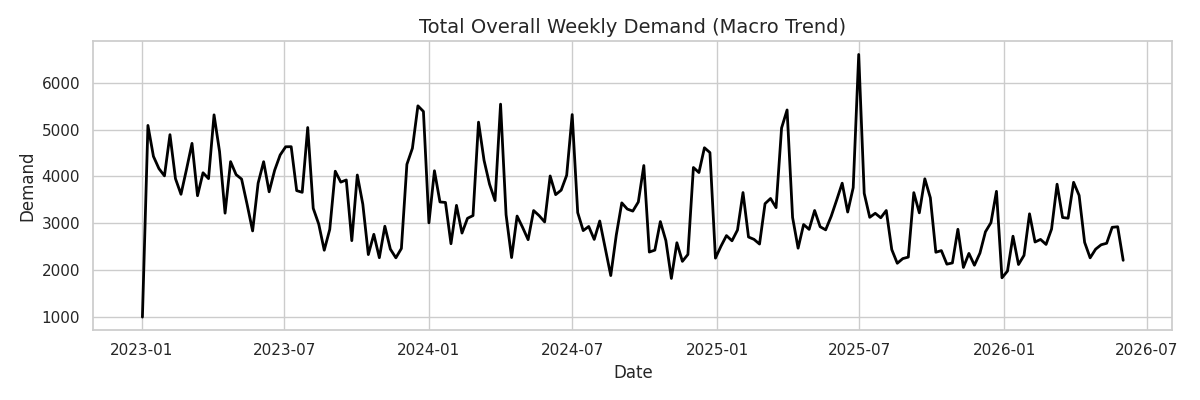

In [12]:
from IPython.display import Image, display

print("### Total Overall Weekly Demand (Macro Trend)")
display(Image('eda_total.png'))

### Weekly Demand by SMU


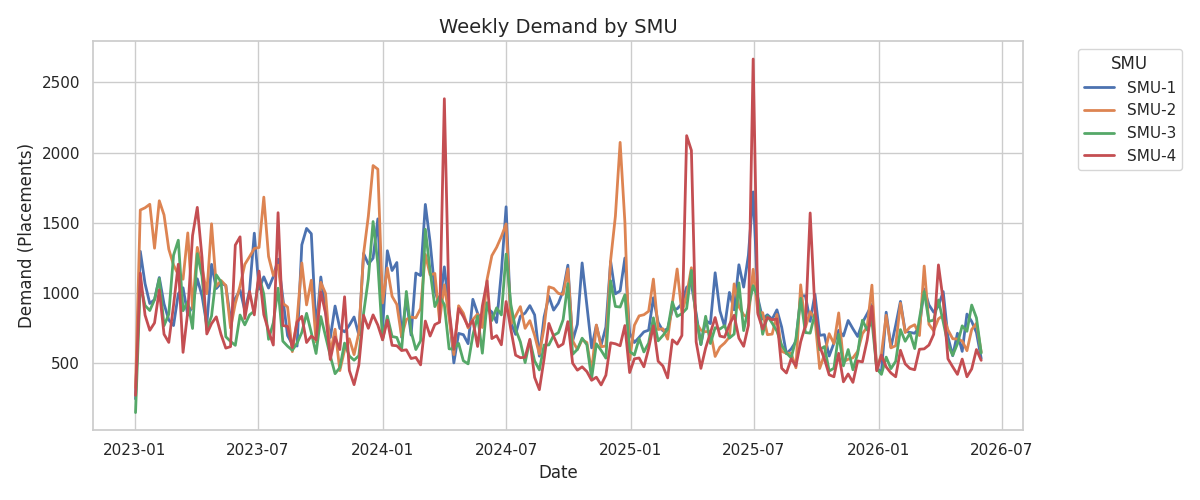

In [13]:
print("### Weekly Demand by SMU")
display(Image('eda_smu.png'))

### Weekly Demand by Service Line (SL)


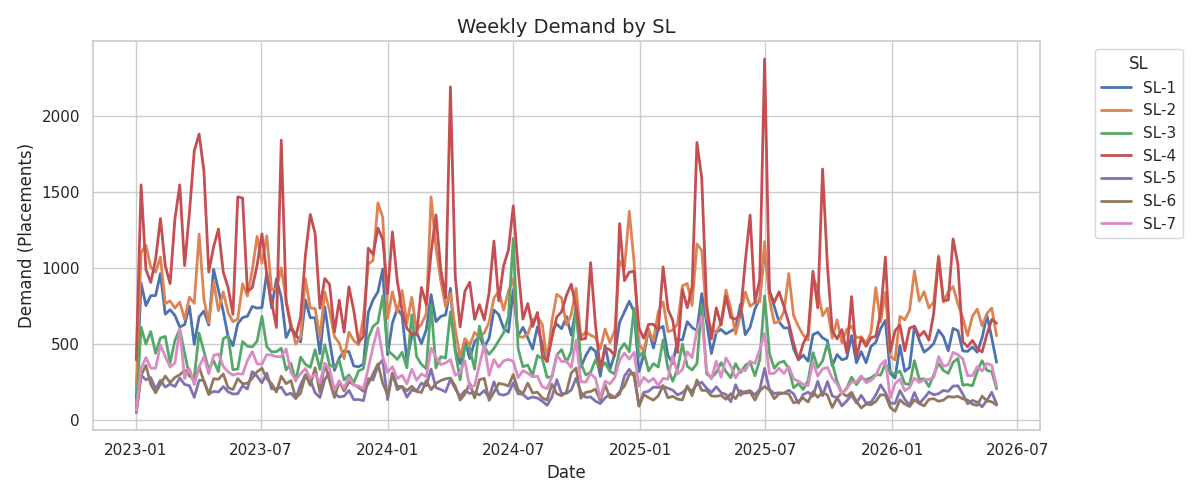

In [14]:
print("### Weekly Demand by Service Line (SL)")
display(Image('eda_sl.png'))

### Weekly Demand by Top 6 Sectors


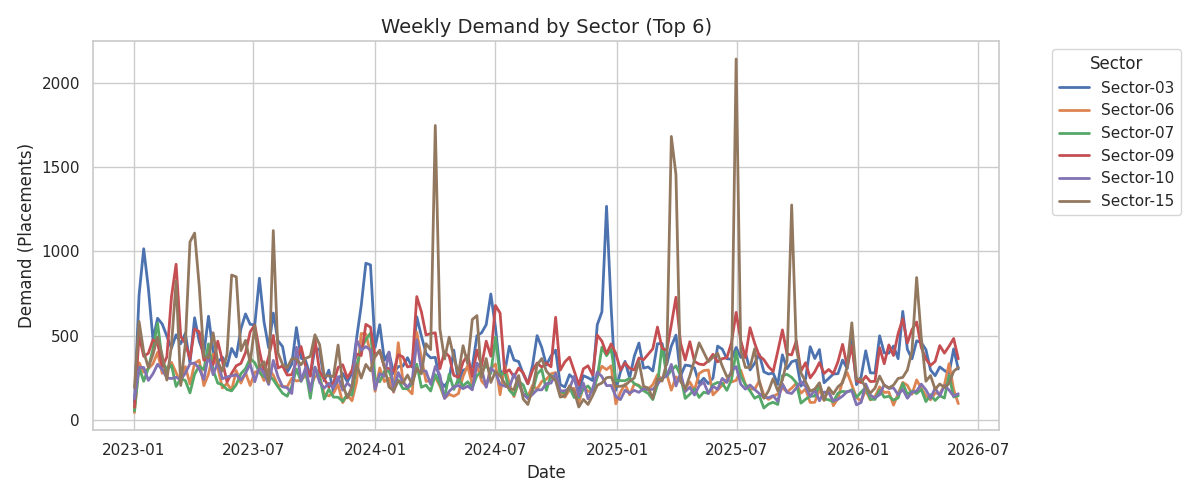

In [15]:
print("### Weekly Demand by Top 6 Sectors")
display(Image('eda_sector_top6.png'))

In [16]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
ds,0
unique_id,0
y,0
SMU,0
SL,0
Sector,0
Location,0
Pricing,0
Type,0
Star,0


### Augmented Dickey-Fuller Test for Stationarity

In [17]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the total overall weekly demand
result = adfuller(total_weekly['y'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nBased on the p-value (%.3f), the series is stationary." % result[1])
else:
    print("\nBased on the p-value (%.3f), the series is not stationary." % result[1])

ADF Statistic: -1.778455
p-value: 0.391209
Critical Values:
	1%: -3.470
	5%: -2.879
	10%: -2.576

Based on the p-value (0.391), the series is not stationary.


### Autocorrelation Function (ACF) Plots

ACF plots help us understand the correlation of a time series with its lagged values. This is crucial for identifying seasonality, trends, and appropriate model orders for time series forecasting.

## ACF PLOTS OF TOTAL, SMU AND SERVICE LINES

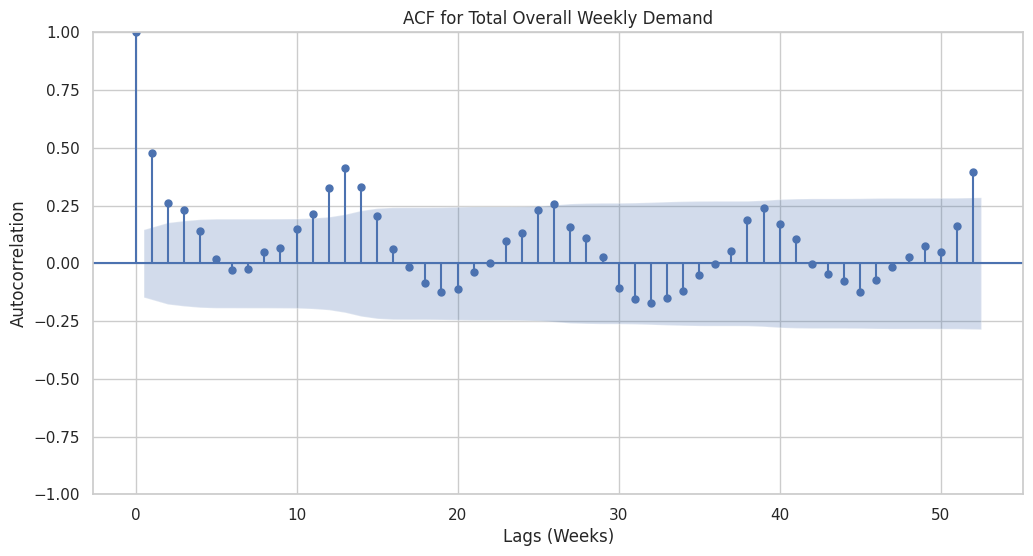

<Figure size 640x480 with 0 Axes>

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Plot ACF for Total Overall Weekly Demand
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(total_weekly['y'], lags=52, ax=ax, title='ACF for Total Overall Weekly Demand')
plt.xlabel('Lags (Weeks)')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

fig_total_acf = fig
plt.savefig("acf_total_overall_weekly_demand.png") # Store the figure object for potential saving


### Interpretation of ACF for Total Overall Weekly Demand

Analyzing the ACF plot for the total overall weekly demand, here's what we can interpret regarding seasonality:

*   **Strong Autocorrelation at Lag 1:** The initial strong spike at lag 1 indicates a significant correlation with the previous week's demand, which is typical for time series data with a trend or short-term persistence.

*   **Annual Seasonality (Lag 52):** There is a clear and significant spike at **lag 52**, which strongly suggests an **annual seasonality**. This means that the demand tends to repeat a similar pattern approximately every 52 weeks (one year).

*   **Semi-Annual and Quarterly Seasonality (Lags 26, 13, 39):** We also observe significant spikes around **lags 13, 26, and 39**. These indicate potential **quarterly and semi-annual seasonal patterns**. The spike at lag 26 suggests a pattern repeating every 26 weeks (half a year), and the spikes around 13 and 39 further support a quarterly cycle.

*   **Overall Pattern:** The autocorrelation generally decreases but shows consistent significant spikes at multiples of roughly 13 weeks, peaking strongly at 52 weeks. This confirms the presence of strong seasonal components, particularly on an annual cycle, with sub-cycles at quarterly and semi-annual frequencies. The negative autocorrelations around lags 18-22 and 30-34 also suggest a fluctuating seasonal pattern rather than a simple monotonic decay.

These seasonal patterns will be very important to consider when building a forecasting model, as they indicate predictable variations in demand throughout the year.

### ACF Plots for Individual SMUs

Examining the ACF for each SMU can reveal distinct seasonal patterns or autocorrelation structures that might be masked in the aggregated total demand.

1. AMERICAS-1
2. AMERICAS-2
3. APMEA
4. EUROPE

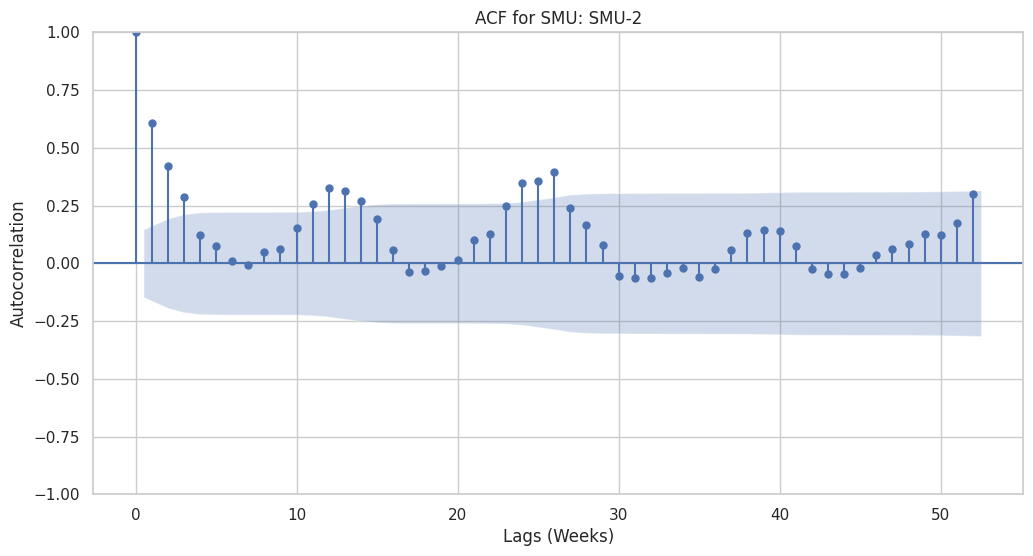

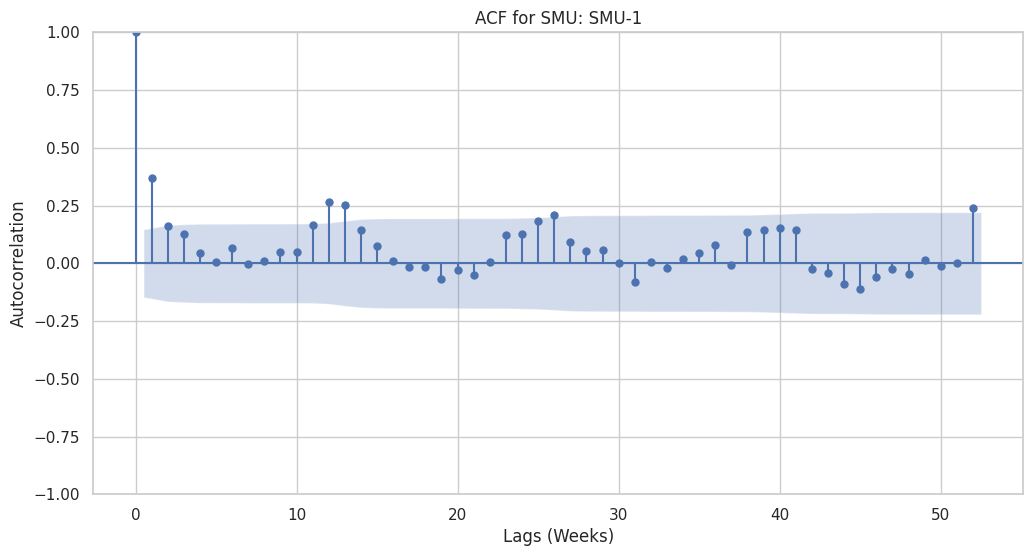

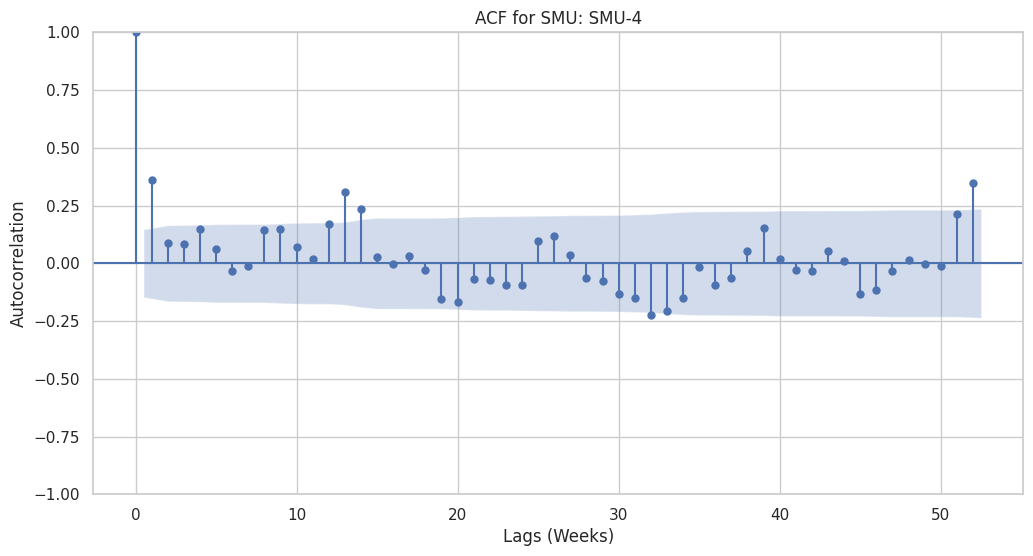

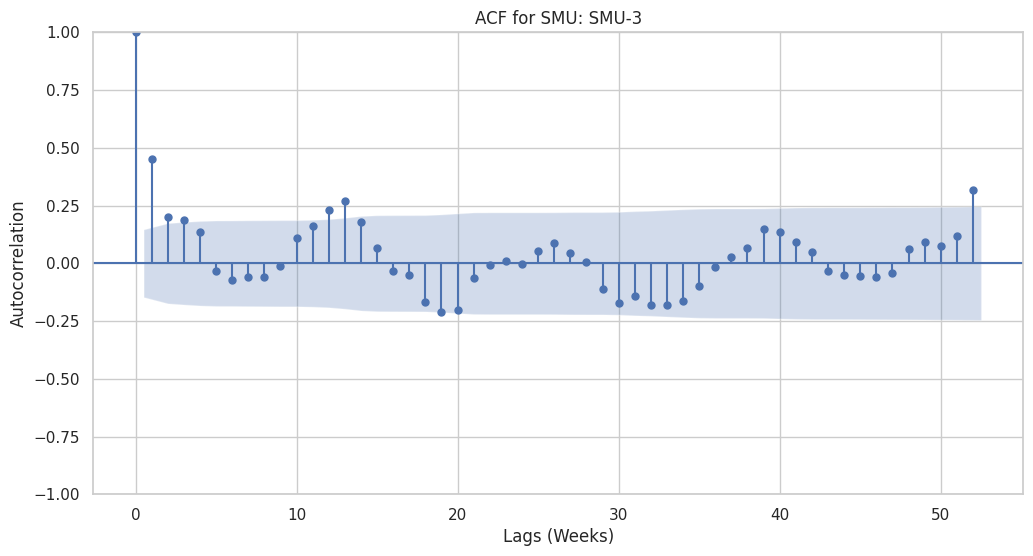

In [19]:
unique_smus = df['SMU'].unique()
smu_acf_figures = {}

for smu in unique_smus:
    smu_data = df[df['SMU'] == smu].groupby(pd.Grouper(key='ds', freq='W-MON'))['y'].sum().reset_index()
    smu_data = smu_data.set_index('ds')

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(smu_data['y'], lags=52, ax=ax, title=f'ACF for SMU: {smu}')
    plt.xlabel('Lags (Weeks)')
    plt.ylabel('Autocorrelation')
    plt.grid(True)
    plt.show()
    smu_acf_figures[smu] = fig # Store the figure object


### ACF Plots for Individual Service Lines

Similarly, analyzing ACF for each Service Line provides insights into their specific demand dynamics.

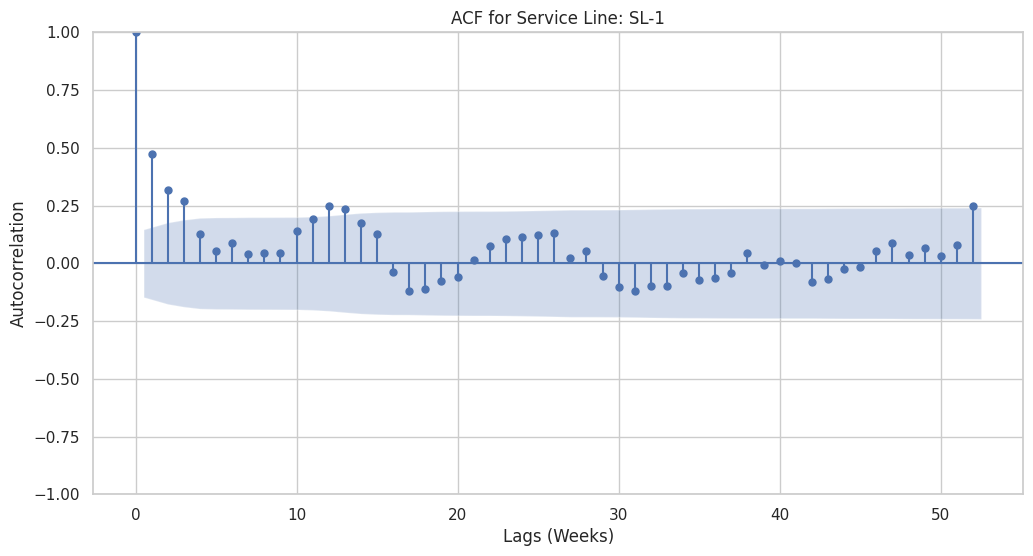

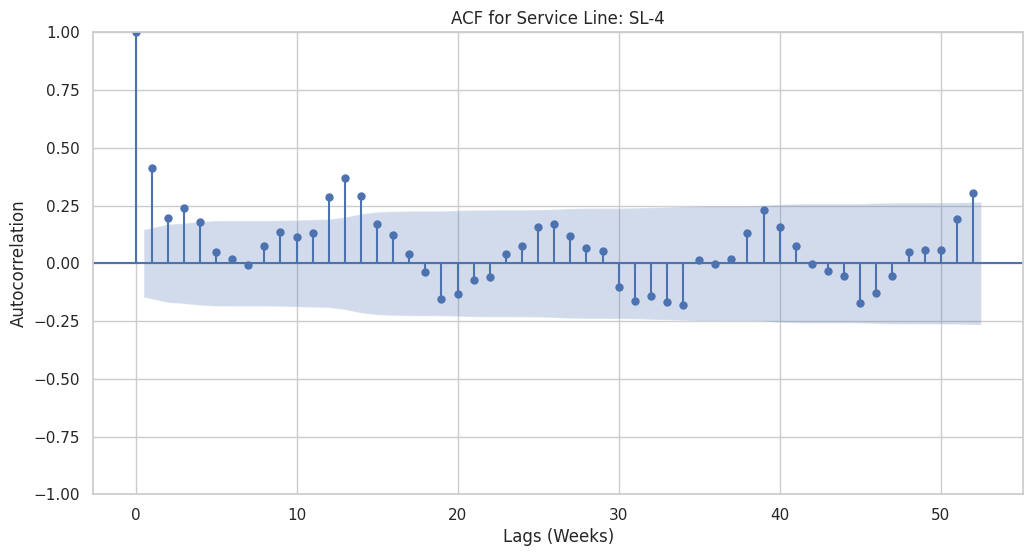

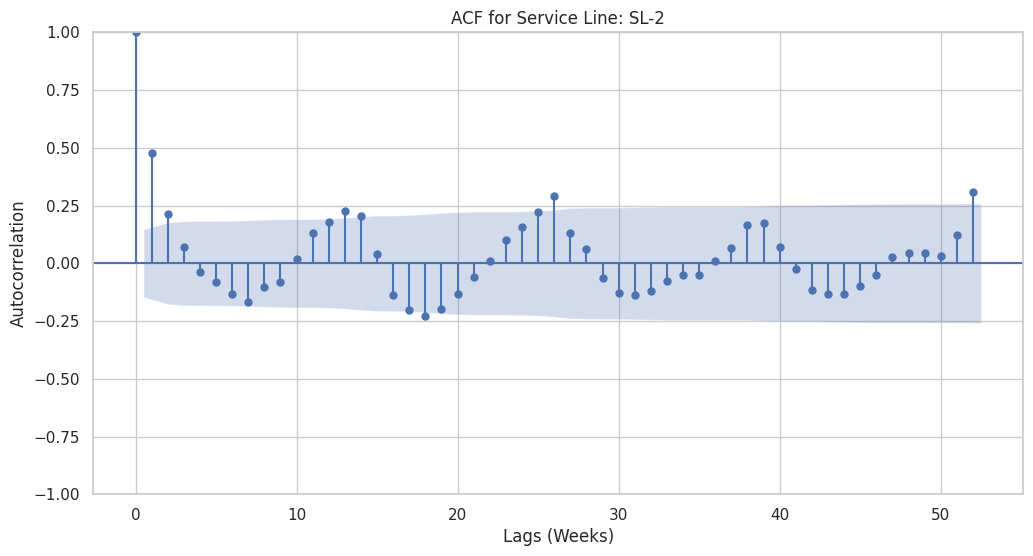

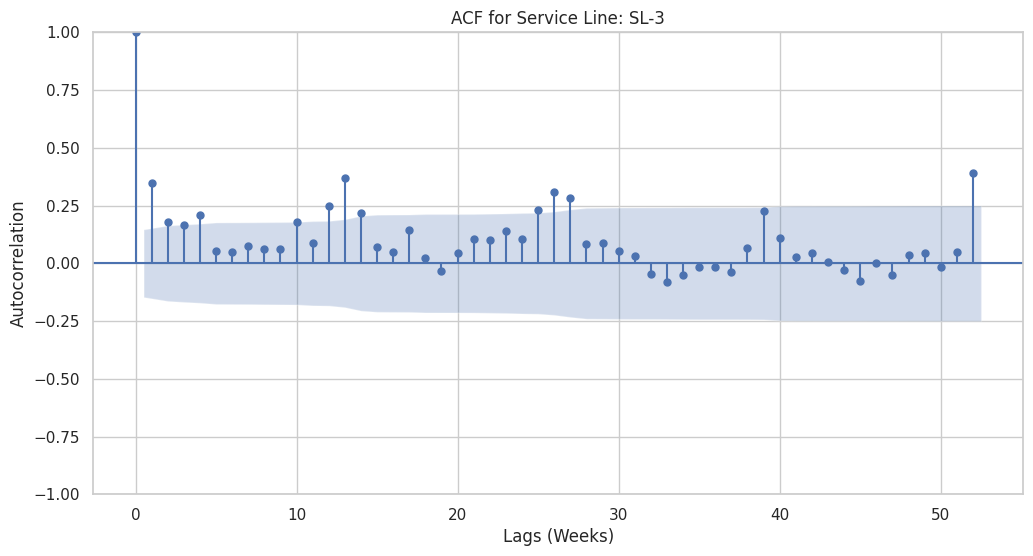

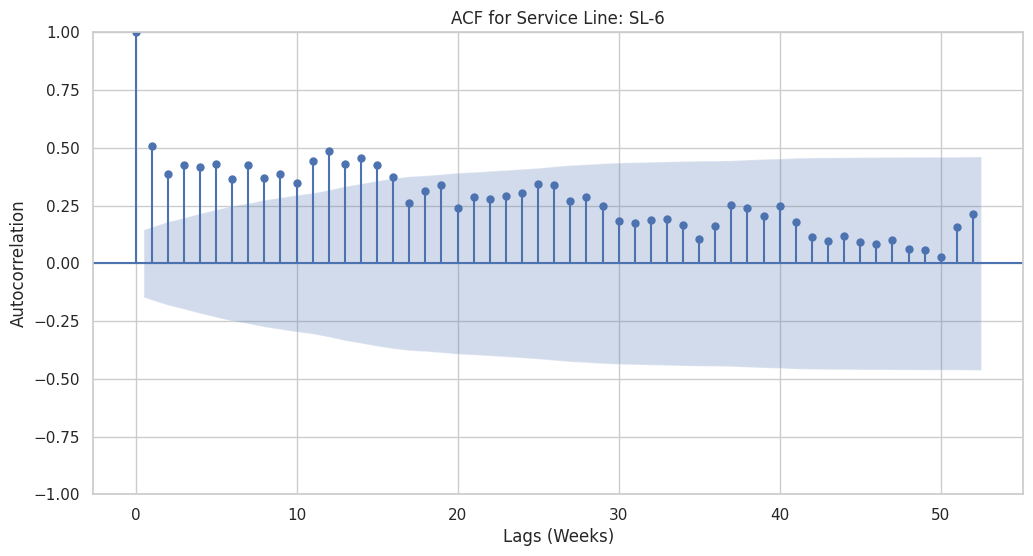

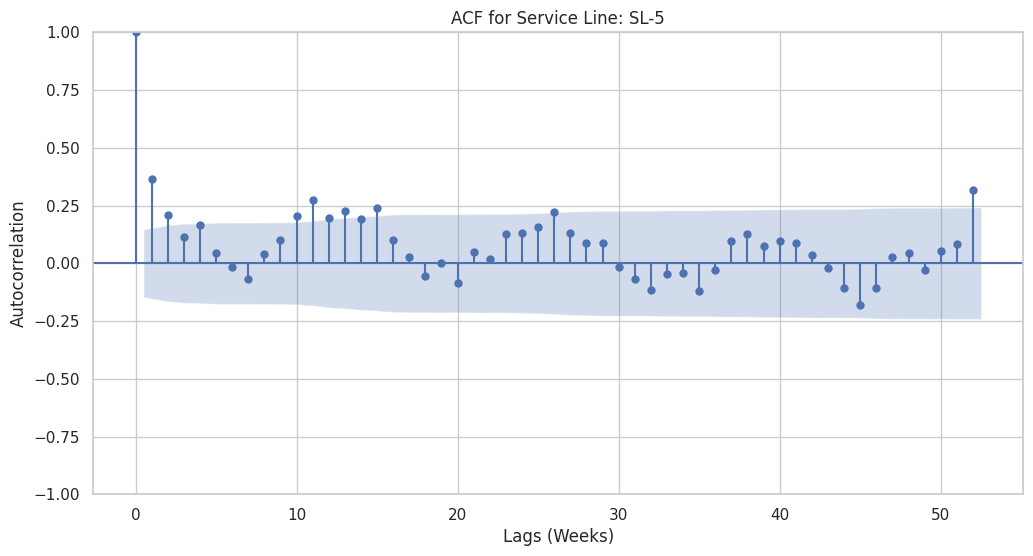

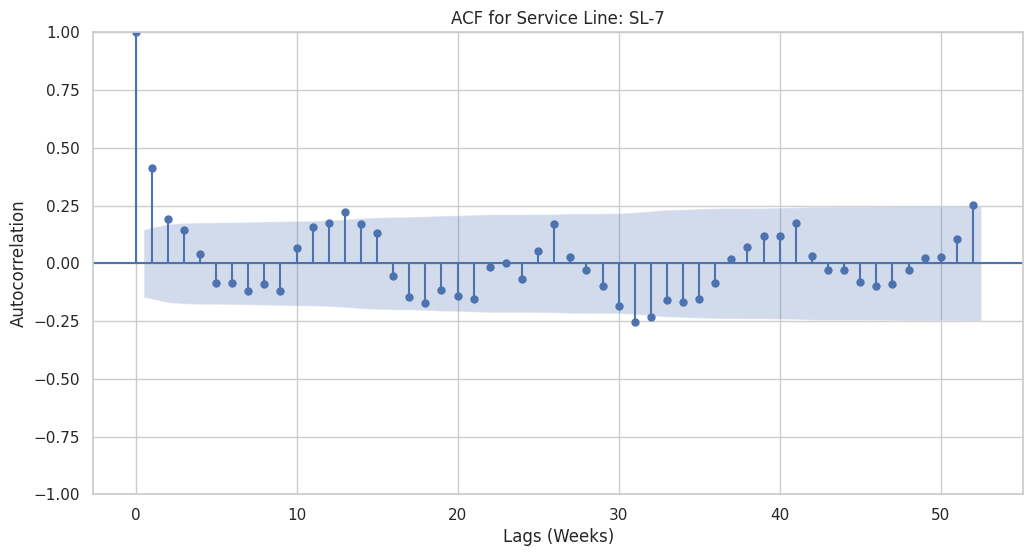

In [20]:
unique_sls = df['SL'].unique()
sl_acf_figures = {}

for sl in unique_sls:
    sl_data = df[df['SL'] == sl].groupby(pd.Grouper(key='ds', freq='W-MON'))['y'].sum().reset_index()
    sl_data = sl_data.set_index('ds')

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(sl_data['y'], lags=52, ax=ax, title=f'ACF for Service Line: {sl}')
    plt.xlabel('Lags (Weeks)')
    plt.ylabel('Autocorrelation')
    plt.grid(True)
    plt.show()
    sl_acf_figures[sl] = fig # Store the figure object


In [21]:
zero_demand_raw = (df['y'] == 0).sum()
total_raw_observations = len(df['y'])

print(f"Number of zero demand values in raw data: {zero_demand_raw}")
print(f"Total number of observations in raw data: {total_raw_observations}")

if zero_demand_raw > 0:
    percentage_zero_raw = (zero_demand_raw / total_raw_observations) * 100
    print(f"Percentage of zero demand values in raw data: {percentage_zero_raw:.2f}%")
    if percentage_zero_raw > 10:
        print("\nThis suggests that the raw demand data might be intermittent (many zero values).")
    else:
        print("\nThe percentage of zero demand in raw data is relatively low.")
else:
    print("\nThere are no zero demand values in the raw dataset, indicating that the demand is not intermittent at the raw level.")

Number of zero demand values in raw data: 0
Total number of observations in raw data: 590576

There are no zero demand values in the raw dataset, indicating that the demand is not intermittent at the raw level.


For non-intermittent data with **multiple seasonalities**, the recommended models are:

1. **MSTL** (Multiple Seasonal Trend decomposition using LOESS) — explicitly designed for multiple seasonal patterns (e.g., daily, weekly, yearly).
2. **TBATS**(Trigonometric seasonality, Box-Cox Transformation, ARMA errors,Trend, Seasonal components)
3. **Prophet**: It is also handle multiple seasonality. Structural Regression Model.
4. **Orbit**: It also handles multiple seasonality. It was created by Uber Engineering Team.


For Reconciliation process we will
```hierarchicalforecast```
module by Nixtla.

1. Top-Bottom
2. Bottom-Top
3. MinTrace

We will calculate the base forecasts using the strict statistical models from above

### Preparing Hierarchical Data for Reconciliation with `aggregate`

We will use the `hierarchicalforecast.utils.aggregate` function to create the full hierarchical dataset (`Y_df`), the summing matrix (`S_df`), and the `tags`. This process starts from our most granular weekly data (grouped by `SMU`, `SL`, and `Sector`) and systematically aggregates it up to higher levels, including a 'Total' sum.

The `spec` defines the hierarchy: from the most granular level (`SMU`, `SL`, `Sector`) up to broader aggregations (`SMU` and `SL` combinations, then just `SMU`). The `aggregate` function automatically handles the creation of the overall 'Total' level.

In [22]:
!pip install hierarchicalforecast statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.7/306.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.1/107.1 kB 10.7 MB/s eta 0:00:00


In [23]:
weekly_data['Total'] = 'Overall'

In [24]:
weekly_data

,ds,SMU,SL,Sector,y,Total
0,2023-01-02,SMU-1,SL-1,Sector-01,8,Overall
1,2023-01-02,SMU-1,SL-1,Sector-04,3,Overall
2,2023-01-02,SMU-1,SL-1,Sector-10,12,Overall
3,2023-01-02,SMU-1,SL-1,Sector-12,3,Overall
4,2023-01-02,SMU-1,SL-1,Sector-13,6,Overall
...,...,...,...,...,...,...
22166,2026-06-01,SMU-4,SL-6,Sector-18,4,Overall
22167,2026-06-01,SMU-4,SL-7,Sector-08,2,Overall
22168,2026-06-01,SMU-4,SL-7,Sector-14,1,Overall
22169,2026-06-01,SMU-4,SL-7,Sector-15,4,Overall


In [25]:
import pandas as pd
from hierarchicalforecast.utils import aggregate

# 1. Define your hierarchy and aggregate the raw data
# Ensure 'Total' column exists in your raw dataframe 'df' if it's the top level of your spec
if 'Total' not in weekly_data.columns:
    df['Total'] = 'Overall'

spec = [
    ['Total'],                                  # Overall Total
    ['Total', 'SMU'],                           # Aggregate by Total and SMU
    ['Total', 'SMU', 'SL'],                     # Aggregate by Total, SMU, and Service Line
    ['Total', 'SMU', 'SL', 'Sector']            # The most granular level
]

# Generate the unified hierarchy.  Assuming 'df' is your raw, bottom-level data
Y_df_agg, S_df, tags = aggregate(df=weekly_data, spec=spec)


# 2. Measure lengths of the AGGREGATED series
series_lengths = Y_df_agg.groupby('unique_id').size()

# 3. Get the IDs for the two groups (using the 104-week rule for annual seasonality)
long_ids = series_lengths[series_lengths >= 104].index
short_ids = series_lengths[series_lengths < 104].index

# 4. Split the AGGREGATED DataFrame
Y_df_long = Y_df_agg[Y_df_agg['unique_id'].isin(long_ids)]
Y_df_short = Y_df_agg[Y_df_agg['unique_id'].isin(short_ids)]

print(f"Number of long series (>= 104 weeks): {len(long_ids)}")
print(f"Number of short series (< 104 weeks): {len(short_ids)}")

Number of long series (>= 104 weeks): 157
Number of short series (< 104 weeks): 13


In [26]:
S_df.head()

,unique_id,Overall/SMU-1/SL-1/Sector-01,Overall/SMU-1/SL-1/Sector-04,Overall/SMU-1/SL-1/Sector-10,Overall/SMU-1/SL-1/Sector-12,Overall/SMU-1/SL-1/Sector-13,Overall/SMU-1/SL-1/Sector-19,Overall/SMU-1/SL-1/Sector-20,Overall/SMU-1/SL-2/Sector-01,Overall/SMU-1/SL-2/Sector-04,...,Overall/SMU-4/SL-6/Sector-15,Overall/SMU-4/SL-6/Sector-16,Overall/SMU-4/SL-6/Sector-17,Overall/SMU-4/SL-6/Sector-18,Overall/SMU-4/SL-7/Sector-08,Overall/SMU-4/SL-7/Sector-14,Overall/SMU-4/SL-7/Sector-15,Overall/SMU-4/SL-7/Sector-16,Overall/SMU-4/SL-7/Sector-17,Overall/SMU-4/SL-7/Sector-18
0,Overall,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Overall/SMU-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Overall/SMU-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Overall/SMU-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Overall/SMU-4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [27]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA

# Define the forecast horizon
h = 12

# 1. Forecast Long Series using MSTL
# MSTL is ideal for series with multiple seasonalities (13, 26, 52 weeks)
print(f"Forecasting {len(long_ids)} long series using MSTL...")
sf_long = StatsForecast(
    models=[MSTL(season_length=[13, 26, 52], trend_forecaster=AutoARIMA())],
    freq='W-MON'
)
forecast_long = sf_long.forecast(df=Y_df_long, h=h)

# 2. Forecast Short Series using AutoARIMA
# AutoARIMA is more robust for shorter series where complex seasonality can't be estimated
if len(short_ids) > 0:
    print(f"Forecasting {len(short_ids)} short series using AutoARIMA...")
    sf_short = StatsForecast(
        models=[AutoARIMA()],
        freq='W-MON'
    )
    forecast_short = sf_short.forecast(df=Y_df_short, h=h)

    # Rename the AutoARIMA column to MSTL to ensure smooth concatenation later
    forecast_short = forecast_short.rename(columns={'AutoARIMA': 'MSTL'})
else:
    forecast_short = pd.DataFrame()

print("Base forecasts for long and short series generated successfully.")

Forecasting 157 long series using MSTL...
Forecasting 13 short series using AutoARIMA...


/usr/local/lib/python3.12/dist-packages/statsforecast/arima.py:1104: RuntimeWarning: divide by zero encountered in scalar divide
  fit["sigma2"] = np.nansum(fit["residuals"] ** 2) / (nstar - npar + 1)


Base forecasts for long and short series generated successfully.


#### 4.1 Concatenate Base Forecasts

First, we concatenate the forecasts generated for long series (using MSTL) and short series (using AutoARIMA). The `StatsForecast` library conveniently outputs `unique_id` as the index, which simplifies the concatenation.

In [28]:
# 1. Simply concatenate the forecasts.
# StatsForecast natively outputs 'unique_id' as the index, so pd.concat preserves it perfectly!
if len(short_ids) > 0:
    base_forecasts_temp = pd.concat([forecast_long, forecast_short])
else:
    base_forecasts_temp = forecast_long.copy()

# Ensure base_forecasts index is string type and reset it to make unique_id a column
base_forecasts_temp.index = base_forecasts_temp.index.astype(str)
base_forecasts_temp = base_forecasts_temp.reset_index()

# Display the head to confirm concatenation
print("Concatenated Base Forecasts:")
display(base_forecasts_temp.head())

Concatenated Base Forecasts:


,index,unique_id,ds,MSTL
0,0,Overall,2026-06-08,2841.222900
1,1,Overall,2026-06-15,2579.252686
2,2,Overall,2026-06-22,3357.693359
3,3,Overall,2026-06-29,4989.919434
4,4,Overall,2026-07-06,2835.658447


In [29]:
S_df.head()

,unique_id,Overall/SMU-1/SL-1/Sector-01,Overall/SMU-1/SL-1/Sector-04,Overall/SMU-1/SL-1/Sector-10,Overall/SMU-1/SL-1/Sector-12,Overall/SMU-1/SL-1/Sector-13,Overall/SMU-1/SL-1/Sector-19,Overall/SMU-1/SL-1/Sector-20,Overall/SMU-1/SL-2/Sector-01,Overall/SMU-1/SL-2/Sector-04,...,Overall/SMU-4/SL-6/Sector-15,Overall/SMU-4/SL-6/Sector-16,Overall/SMU-4/SL-6/Sector-17,Overall/SMU-4/SL-6/Sector-18,Overall/SMU-4/SL-7/Sector-08,Overall/SMU-4/SL-7/Sector-14,Overall/SMU-4/SL-7/Sector-15,Overall/SMU-4/SL-7/Sector-16,Overall/SMU-4/SL-7/Sector-17,Overall/SMU-4/SL-7/Sector-18
0,Overall,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Overall/SMU-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Overall/SMU-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Overall/SMU-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Overall/SMU-4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [30]:
import pandas as pd

# Get IDs from both sources
s_ids = set(S_df.index.astype(str))
forecast_ids = set(base_forecasts_temp['unique_id'].unique().astype(str))

# Find IDs in S_df missing from base_forecasts
missing_in_forecast = s_ids - forecast_ids
extra_in_forecast = forecast_ids - s_ids

print(f"Total unique IDs in S_df: {len(s_ids)}")
print(f"Total unique IDs in base_forecasts: {len(forecast_ids)}")

if missing_in_forecast:
    print(f"\nFound {len(missing_in_forecast)} IDs in S_df that are MISSING in base_forecasts:")
    print(sorted(list(missing_in_forecast))[:20], "..." if len(missing_in_forecast) > 20 else "")
else:
    print("\nSuccess: All IDs in S_df are present in base_forecasts.")

if extra_in_forecast:
    print(f"\nFound {len(extra_in_forecast)} IDs in base_forecasts NOT in S_df index:")
    print(sorted(list(extra_in_forecast))[:20], "..." if len(extra_in_forecast) > 20 else "")

Total unique IDs in S_df: 170
Total unique IDs in base_forecasts: 170

Found 170 IDs in S_df that are MISSING in base_forecasts:
['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115'] ...

Found 170 IDs in base_forecasts NOT in S_df index:
[np.str_('Overall'), np.str_('Overall/SMU-1'), np.str_('Overall/SMU-1/SL-1'), np.str_('Overall/SMU-1/SL-1/Sector-01'), np.str_('Overall/SMU-1/SL-1/Sector-04'), np.str_('Overall/SMU-1/SL-1/Sector-10'), np.str_('Overall/SMU-1/SL-1/Sector-12'), np.str_('Overall/SMU-1/SL-1/Sector-13'), np.str_('Overall/SMU-1/SL-1/Sector-19'), np.str_('Overall/SMU-1/SL-1/Sector-20'), np.str_('Overall/SMU-1/SL-2'), np.str_('Overall/SMU-1/SL-2/Sector-01'), np.str_('Overall/SMU-1/SL-2/Sector-04'), np.str_('Overall/SMU-1/SL-2/Sector-10'), np.str_('Overall/SMU-1/SL-2/Sector-12'), np.str_('Overall/SMU-1/SL-2/Sector-13'), np.str_('Overall/SMU-1/SL-2/Sector-19'), np.str_('Overall/SMU-1/SL-2/Sector-20'

In [31]:
if 'index' in base_forecasts_temp.columns:
    base_forecasts_temp = base_forecasts_temp.drop(columns=['index'])

# Also ensure any other residual indices are cleaned up
base_forecasts_temp = base_forecasts_temp.loc[:, ~base_forecasts_temp.columns.str.contains('^Unnamed')]

print("Cleaned Base Forecasts (Index column removed):")
display(base_forecasts_temp.head())

Cleaned Base Forecasts (Index column removed):


,unique_id,ds,MSTL
0,Overall,2026-06-08,2841.222900
1,Overall,2026-06-15,2579.252686
2,Overall,2026-06-22,3357.693359
3,Overall,2026-06-29,4989.919434
4,Overall,2026-07-06,2835.658447


#### 4.3 Sort `base_forecasts` and Set Index

To ensure proper alignment during reconciliation, we need to sort the `base_forecasts` DataFrame. We achieve this by converting `'unique_id'` to a categorical type, ordered according to the unique IDs in our `S_df`, and then sorting by this categorical column and `ds` (date). Finally, we set `'unique_id'` back as the index.

In [32]:
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

# 1. Prepare base_forecasts for reconciliation
base_forecasts = base_forecasts_temp.copy()

# Ensure unique_id is a string column
base_forecasts['unique_id'] = base_forecasts['unique_id'].astype(str)

# Sort based on the S_df index to ensure alignment
sorted_ids = S_df.index.tolist()
base_forecasts['unique_id'] = pd.Categorical(base_forecasts['unique_id'], categories=sorted_ids, ordered=True)
base_forecasts = base_forecasts.sort_values(['unique_id', 'ds']).reset_index(drop=True)
base_forecasts['unique_id'] = base_forecasts['unique_id'].astype(str)

# 2. Initialize the Reconciler
hrec = HierarchicalReconciliation(
    reconcilers=[BottomUp(), MinTrace(method='ols')]
)

# 3. Reconcile the forecasts
# Note: S_df_for_reconciliation should have unique_id as its INDEX
reconciled_df = hrec.reconcile(
    Y_hat_df=base_forecasts_temp,
    S_df=S_df,
    tags=tags
)

print("Final Reconciled Forecasts (Production):")
display(reconciled_df.head())

Final Reconciled Forecasts (Production):


,unique_id,ds,MSTL,MSTL/BottomUp,MSTL/MinTrace_method-ols
0,Overall,2026-06-08,2841.222900,3037.188626,2855.184289
1,Overall,2026-06-15,2579.252686,2767.907568,2581.765258
2,Overall,2026-06-22,3357.693359,3463.583951,3362.796769
3,Overall,2026-06-29,4989.919434,5027.018301,4997.063233
4,Overall,2026-07-06,2835.658447,3073.907203,2847.393010


The hierarchicalforecast library (built by Nixtla) has undergone some massive updates recently to make it faster and compatible with large-scale distributed computing frameworks like Spark and Polars.
If you are looking at recent documentation or upgrading your environment, here are the three major updates regarding how S_df (the Summation Matrix) is handled during base forecasting and reconciliation:
### 1. The Parameter Renaming (S to S_df)
In older versions of the library, when you called the reconcile() method, the parameter for the summation matrix was simply named S. To standardize the naming conventions across the ecosystem (matching Y_df and Y_hat_df), this was recently officially renamed.
 * **Old Way:** hrec.reconcile(Y_hat_df=..., S=Summation_Matrix, tags=...)
 * **New Update:** hrec.reconcile(Y_hat_df=..., S_df=Summation_Matrix, tags=...)
### 2. The unique_id Alignment (Index vs. Column)
This is the exact update that caused the KeyError you saw earlier!
 * **Base Forecasts (Y_hat_df):** In the past, the library required unique_id to be the DataFrame index. The latest update **requires unique_id to be a standard column** for base forecasts so that the data is compatible with Polars and distributed computing.
 * **The Summation Matrix (S_df):** Unlike the base forecasts, the aggregate() function still generates S_df with the unique_id strings acting as the **Index** (the row names). The internal reconciler has been updated to automatically match the unique_id column in your forecasts against the Index of your S_df.
### 3. Sparse Matrix Support (The Biggest Performance Update)
If you have a massive hierarchy with thousands of sectors, a standard S_df DataFrame becomes mostly zeros (0.0), which wastes gigabytes of RAM.
The latest update introduced the sparse_s=True parameter to the aggregate() function.
```python
# The New Update
Y_df, S_df, tags = aggregate(df=bottom_data, spec=spec, sparse_s=True)

```
When you use sparse_s=True, it generates an optimized SMatrix instead of a dense pandas DataFrame. The reconcile() method, specifically computationally heavy ones like MinTrace, was completely rewritten in C++ under the hood to accept this sparse matrix, drastically reducing memory usage and speeding up reconciliation by up to 100x for large supply chains!


In [33]:
min_series_length = series_lengths.min()
print(f"The minimum series length is: {min_series_length} weeks")

The minimum series length is: 3 weeks


In [34]:
len(reconciled_df['unique_id'].unique())

170

In [35]:
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Define the holdout period for evaluation
h = 12

# Ensure Y_df_agg is sorted chronologically for consistent splitting
Y_df_agg = Y_df_agg.sort_values(['unique_id', 'ds'])

# 2. Split historical aggregated data into Train and Test sets
# Y_test_df contains the last 'h' periods for each unique_id
Y_test_df_eval = Y_df_agg.groupby('unique_id').tail(h)
# Y_train_df contains all data except the holdout periods
Y_train_df_eval = Y_df_agg.drop(Y_test_df_eval.index)

print(f"Original Y_df_agg shape: {Y_df_agg.shape}")
print(f"Training data shape (Y_train_df_eval): {Y_train_df_eval.shape}")
print(f"Testing data shape (Y_test_df_eval): {Y_test_df_eval.shape}")

display(Y_train_df_eval.head())
display(Y_test_df_eval.head())

Original Y_df_agg shape: (28078, 3)
Training data shape (Y_train_df_eval): (26049, 3)
Testing data shape (Y_test_df_eval): (2029, 3)


,unique_id,ds,y
0,Overall,2023-01-02,989
1,Overall,2023-01-09,5090
2,Overall,2023-01-16,4428
3,Overall,2023-01-23,4166
4,Overall,2023-01-30,4011


,unique_id,ds,y
167,Overall,2026-03-16,3120
168,Overall,2026-03-23,3105
169,Overall,2026-03-30,3873
170,Overall,2026-04-06,3593
171,Overall,2026-04-13,2589


In [36]:
start_date = Y_test_df_eval['ds'].min()
end_date = Y_test_df_eval['ds'].max()

print(f"The predictions in Y_test_df_eval cover the period from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
print(f"This range includes weeks within Quarter 1 (March 2026) and Quarter 2 (April, May, and early June 2026).")

The predictions in Y_test_df_eval cover the period from 2023-01-23 to 2026-06-01.
This range includes weeks within Quarter 1 (March 2026) and Quarter 2 (April, May, and early June 2026).


In [37]:
# 3. Identify Long vs Short series in TRAINING set
# We define 'long' series as those with 104 or more weekly observations (2 years) for MSTL.
# 'Short' series are those with fewer than 104 observations.
series_lengths_train_eval = Y_train_df_eval.groupby('unique_id').size()
long_ids_train_eval = series_lengths_train_eval[series_lengths_train_eval >= 104].index
short_ids_train_eval = series_lengths_train_eval[series_lengths_train_eval < 104].index

# Filter the training data based on these IDs
Y_train_long_eval = Y_train_df_eval[Y_train_df_eval['unique_id'].isin(long_ids_train_eval)]
Y_train_short_eval = Y_train_df_eval[Y_train_df_eval['unique_id'].isin(short_ids_train_eval)]

print(f"Number of long series in training data (>= 104 weeks): {len(long_ids_train_eval)}")
print(f"Number of short series in training data (< 104 weeks): {len(short_ids_train_eval)}")

display(Y_train_long_eval.head())
display(Y_train_short_eval.head())

Number of long series in training data (>= 104 weeks): 154
Number of short series in training data (< 104 weeks): 14


,unique_id,ds,y
0,Overall,2023-01-02,989
1,Overall,2023-01-09,5090
2,Overall,2023-01-16,4428
3,Overall,2023-01-23,4166
4,Overall,2023-01-30,4011


,unique_id,ds,y
6980,Overall/SMU-1/SL-1/Sector-20,2024-07-01,3
6981,Overall/SMU-1/SL-1/Sector-20,2024-08-26,1
6982,Overall/SMU-1/SL-1/Sector-20,2024-09-30,1
6983,Overall/SMU-1/SL-1/Sector-20,2024-11-11,2
6984,Overall/SMU-1/SL-1/Sector-20,2024-11-18,1


In [38]:
# 4. Generate Base Forecasts using MSTL for long series and AutoARIMA for short series
print(f"Starting MSTL Training on -> Long series: {len(long_ids_train_eval)}, Short series: {len(short_ids_train_eval)}")
print("Please wait, MSTL forecasting can be computationally intensive...")

# Initialize MSTL for long series
sf_long_mstl = StatsForecast(
    models=[MSTL(season_length=[13, 26, 52], trend_forecaster=AutoARIMA())],
    freq='W-MON'
)
forecast_long_mstl = sf_long_mstl.forecast(df=Y_train_long_eval, h=h)

# Initialize AutoARIMA for short series
if len(short_ids_train_eval) > 0:
    sf_short_arima = StatsForecast(models=[AutoARIMA()], freq='W-MON')
    forecast_short_arima = sf_short_arima.forecast(df=Y_train_short_eval, h=h)

    # Rename AutoARIMA column to MSTL to allow concatenation
    forecast_short_arima = forecast_short_arima.rename(columns={'AutoARIMA': 'MSTL'})

    # Concatenate forecasts from long and short series
    base_forecasts_eval = pd.concat([forecast_long_mstl, forecast_short_arima]).reset_index()
else:
    # If no short series, just use the long series forecasts
    base_forecasts_eval = forecast_long_mstl.reset_index()

# Drop any extraneous 'index' column that might have been created by reset_index()
if 'index' in base_forecasts_eval.columns:
    base_forecasts_eval = base_forecasts_eval.drop(columns=['index'])

# Ensure 'unique_id' column in base_forecasts_eval is string type
base_forecasts_eval['unique_id'] = base_forecasts_eval['unique_id'].astype(str)

# Display the first few rows of the combined base forecasts
print("Base forecasts generated and combined:")
display(base_forecasts_eval.head())

print(f"Total base forecasts generated: {len(base_forecasts_eval)}")

Starting MSTL Training on -> Long series: 154, Short series: 14
Please wait, MSTL forecasting can be computationally intensive...
Base forecasts generated and combined:


,unique_id,ds,MSTL
0,Overall,2026-03-16,2875.922607
1,Overall,2026-03-23,3786.470459
2,Overall,2026-03-30,4971.067383
3,Overall,2026-04-06,2509.973145
4,Overall,2026-04-13,1928.207520


Total base forecasts generated: 2016


In [39]:
base_forecasts_eval.head()

,unique_id,ds,MSTL
0,Overall,2026-03-16,2875.922607
1,Overall,2026-03-23,3786.470459
2,Overall,2026-03-30,4971.067383
3,Overall,2026-04-06,2509.973145
4,Overall,2026-04-13,1928.207520


In [40]:
# 5. Reconcile the Base Forecasts

# Initialize the Reconciler
hrec_eval = HierarchicalReconciliation(
    reconcilers=[BottomUp(), MinTrace(method='ols')]
)
print("Hierarchical Reconciler initialized for evaluation.")

# Ensure S_df_for_reconciliation is in the correct format (unique_id as column)
# It was prepared this way in cell 70877fd4.

# --- FIX: Filter S_df_for_reconciliation to match unique_ids in base_forecasts_eval ---
# Get the unique_ids present in the base_forecasts_eval
forecasted_ids = base_forecasts_eval['unique_id'].unique()

# Filter rows of S_df_for_reconciliation based on its 'unique_id' column
S_df_filtered_rows = S_df[S_df['unique_id'].isin(forecasted_ids)]

# Identify columns (bottom-level series) in S_df that are also in forecasted_ids
# The first column is 'unique_id', which is always kept
bottom_level_cols = [col for col in S_df_filtered_rows.columns if col in forecasted_ids or col == 'unique_id']
S_df_final_for_reconciliation = S_df_filtered_rows[bottom_level_cols].copy()

# Important: Set 'unique_id' back as the index for reconciliation after filtering,
# as the reconcile method sometimes expects it as index for S_df,
# despite the earlier error suggesting it should be a column. This part of the library
# can be inconsistent depending on the version and specific reconcile method.



# Reconcile the forecasts
# Y_hat_df needs 'unique_id' as a column, which base_forecasts_eval has.
# S_df needs 'unique_id' as its index, which S_df_final_for_reconciliation now has.
reconciled_mstl_eval = hrec_eval.reconcile(
    Y_hat_df=base_forecasts_eval,
    S_df=S_df_final_for_reconciliation, # Use the filtered and indexed S_df
    tags=tags
)

print("Forecasts reconciled successfully!")

# Display the first few rows of the reconciled forecasts
display(reconciled_mstl_eval.head())

Hierarchical Reconciler initialized for evaluation.
Forecasts reconciled successfully!


,unique_id,ds,MSTL,MSTL/BottomUp,MSTL/MinTrace_method-ols
0,Overall,2026-03-16,2875.922607,2974.869298,2884.919666
1,Overall,2026-03-23,3786.470459,3871.505831,3806.168470
2,Overall,2026-03-30,4971.067383,4878.932628,4980.609464
3,Overall,2026-04-06,2509.973145,2738.556757,2522.681054
4,Overall,2026-04-13,1928.207520,2179.525754,1939.944159


In [41]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 6. Evaluate Accuracy
eval_df_mstl = reconciled_mstl_eval.reset_index().merge(
    Y_test_df_eval[['unique_id', 'ds', 'y']],
    on=['unique_id', 'ds'],
    how='inner'
)

def wmape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

print("\n==================================================")
print("   MSTL MODEL ACCURACY METRICS (All Levels)")
print("==================================================")
models_to_evaluate_mstl = ['MSTL', 'MSTL/BottomUp', 'MSTL/MinTrace_method-ols']

for model in models_to_evaluate_mstl:
    mae = mean_absolute_error(eval_df_mstl['y'], eval_df_mstl[model])
    rmse = np.sqrt(mean_squared_error(eval_df_mstl['y'], eval_df_mstl[model]))
    wmape_score = wmape(eval_df_mstl['y'], eval_df_mstl[model])

    print(f"\n{model}")
    print(f"  MAE:   {mae:.2f}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  WMAPE: {wmape_score:.2f}%")
print("==================================================")


   MSTL MODEL ACCURACY METRICS (All Levels)

MSTL
  MAE:   24.54
  RMSE:  75.46
  WMAPE: 33.48%

MSTL/BottomUp
  MAE:   23.67
  RMSE:  70.57
  WMAPE: 32.29%

MSTL/MinTrace_method-ols
  MAE:   24.96
  RMSE:  75.31
  WMAPE: 34.06%


In [42]:
def get_level(unique_id):
    parts = unique_id.split('/')
    if len(parts) == 1:
        return 'Total'
    elif len(parts) == 2:
        return 'SMU'
    elif len(parts) == 3:
        return 'SMU/SL'
    elif len(parts) == 4:
        return 'SMU/SL/Sector'
    return 'Unknown'

eval_df_mstl['hierarchy_level'] = eval_df_mstl['unique_id'].apply(get_level)

print("\n==================================================")
print("   MSTL MODEL ACCURACY METRICS BY HIERARCHY LEVEL")
print("==================================================")

for level, level_df in eval_df_mstl.groupby('hierarchy_level'):
    print(f"\nHierarchy Level: {level}")
    print("--------------------------------------------------")
    for model in models_to_evaluate_mstl:
        if model in level_df.columns:
            # Filter out negative 'y' values before WMAPE calculation if they exist
            # to avoid division by zero or misleading percentages.
            # For MAE and RMSE, negative predictions are fine.
            positive_y_true = level_df['y'][level_df['y'] > 0]
            model_predictions = level_df[model][level_df['y'] > 0]

            if len(positive_y_true) > 0:
                mae = mean_absolute_error(level_df['y'], level_df[model])
                rmse = np.sqrt(mean_squared_error(level_df['y'], level_df[model]))
                wmape_score = wmape(positive_y_true, model_predictions)

                print(f"  {model}")
                print(f"    MAE:   {mae:.2f}")
                print(f"    RMSE:  {rmse:.2f}")
                print(f"    WMAPE: {wmape_score:.2f}%")
            else:
                print(f"  {model}: No positive 'y' values to calculate WMAPE for this level.")
        else:
            print(f"  Model '{model}' not found in DataFrame for level {level}")
    print("==================================================")


   MSTL MODEL ACCURACY METRICS BY HIERARCHY LEVEL

Hierarchy Level: SMU
--------------------------------------------------
  MSTL
    MAE:   176.36
    RMSE:  255.28
    WMAPE: 24.81%
  MSTL/BottomUp
    MAE:   161.02
    RMSE:  235.38
    WMAPE: 22.65%
  MSTL/MinTrace_method-ols
    MAE:   176.21
    RMSE:  252.94
    WMAPE: 24.79%

Hierarchy Level: SMU/SL
--------------------------------------------------
  MSTL
    MAE:   38.72
    RMSE:  73.22
    WMAPE: 38.13%
  MSTL/BottomUp
    MAE:   37.76
    RMSE:  72.90
    WMAPE: 37.18%
  MSTL/MinTrace_method-ols
    MAE:   39.44
    RMSE:  73.45
    WMAPE: 38.84%

Hierarchy Level: SMU/SL/Sector
--------------------------------------------------
  MSTL
    MAE:   12.65
    RMSE:  32.72
    WMAPE: 54.04%
  MSTL/BottomUp
    MAE:   12.65
    RMSE:  32.72
    WMAPE: 54.04%
  MSTL/MinTrace_method-ols
    MAE:   13.02
    RMSE:  32.85
    WMAPE: 55.65%

Hierarchy Level: Total
--------------------------------------------------
  MSTL
    MAE:   

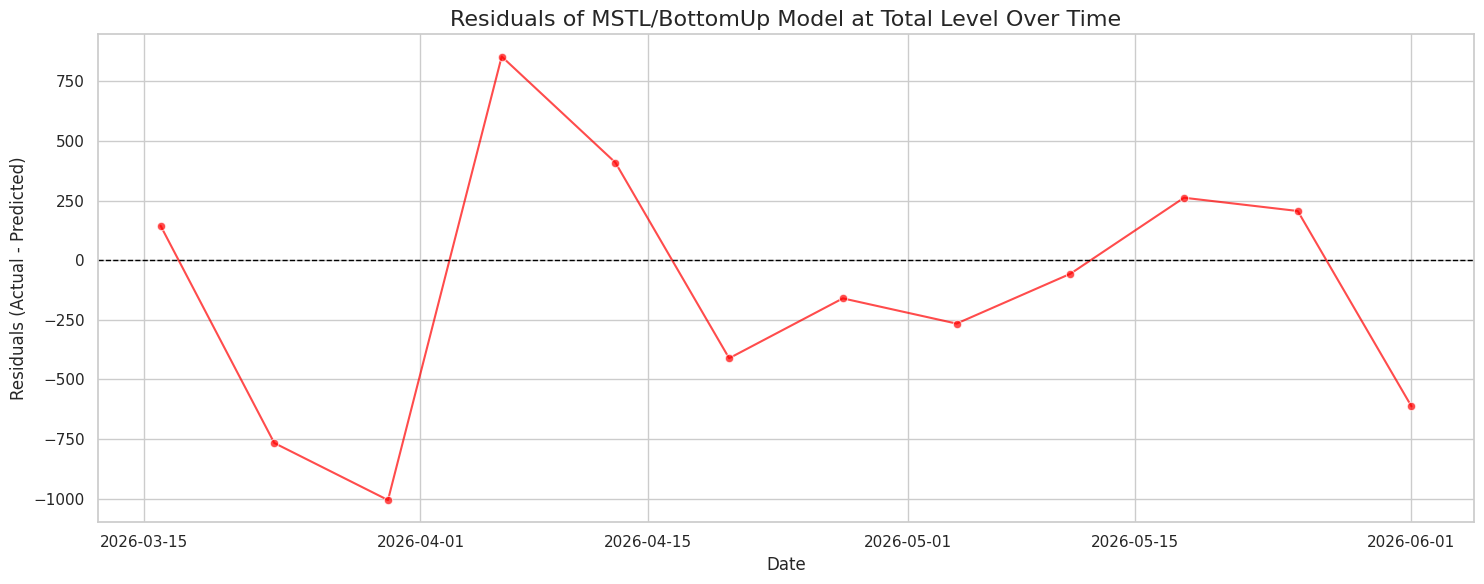

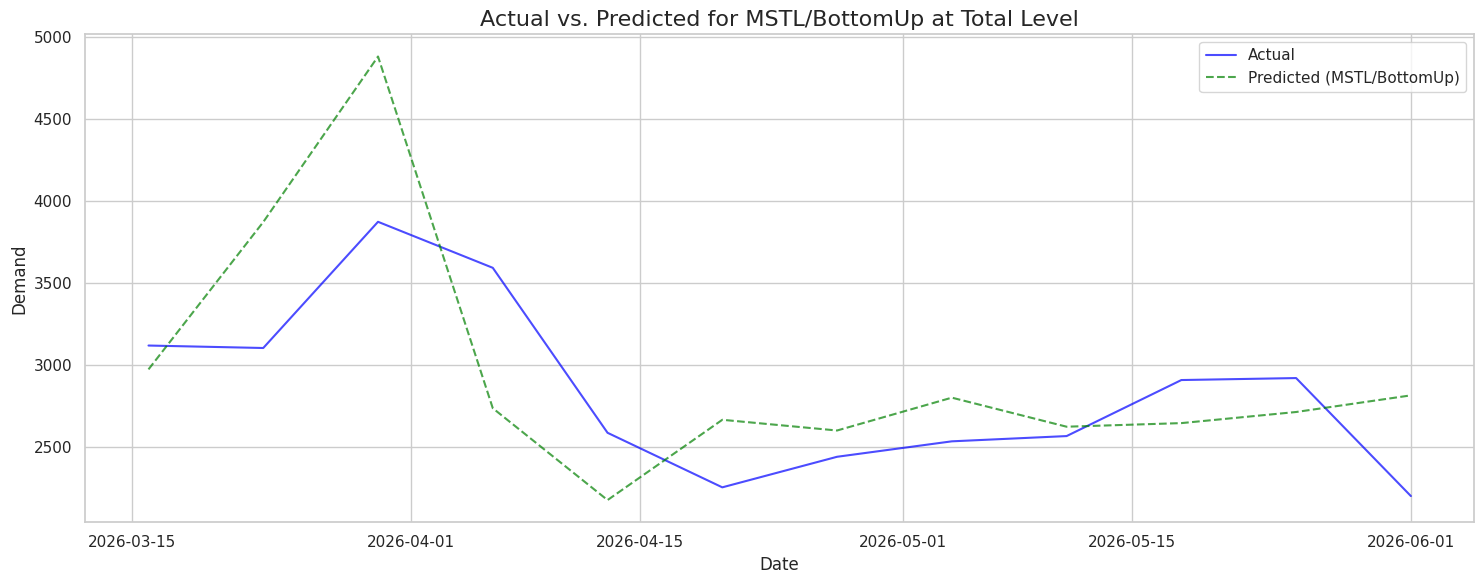

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Total' level data
total_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'Total'].copy()

# Calculate residuals for the best model at 'Total' level (MSTL/BottomUp)
total_level_df['residuals'] = total_level_df['y'] - total_level_df['MSTL/BottomUp']

# Sort by date for proper time series plotting
total_level_df = total_level_df.sort_values(by='ds')

plt.figure(figsize=(15, 6))
sns.lineplot(data=total_level_df, x='ds', y='residuals', marker='o', linestyle='-', color='red', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals of MSTL/BottomUp Model at Total Level Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally, plot actual vs predicted for the Total level to see the fit
plt.figure(figsize=(15, 6))
sns.lineplot(data=total_level_df, x='ds', y='y', label='Actual', color='blue', alpha=0.7)
sns.lineplot(data=total_level_df, x='ds', y='MSTL/BottomUp', label='Predicted (MSTL/BottomUp)', color='green', linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted for MSTL/BottomUp at Total Level', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# @title 📊 MSTL Residual Analysis Dashboard {display-mode: "form"}

import pandas as pd
import numpy as np
import json
import base64
from IPython.display import HTML
from google.colab import output
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prepare Data for Dashboard
total_eval_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'Total'].copy().sort_values('ds')
total_eval_df['residuals'] = total_eval_df['y'] - total_eval_df['MSTL/BottomUp']

# Calculate Metrics
mae_val = mean_absolute_error(total_eval_df['y'], total_eval_df['MSTL/BottomUp'])
rmse_val = np.sqrt(mean_squared_error(total_eval_df['y'], total_eval_df['MSTL/BottomUp']))
wmape_val = (np.sum(np.abs(total_eval_df['y'] - total_eval_df['MSTL/BottomUp'])) / np.sum(np.abs(total_eval_df['y']))) * 100

def calc_ratio(y_t, y_p):
    m_v = np.minimum(y_t, y_p)
    M_v = np.maximum(y_t, y_p)
    return np.mean(np.where(M_v == 0, 1.0, m_v / M_v))

ratio_val = calc_ratio(total_eval_df['y'].values, total_eval_df['MSTL/BottomUp'].values)

# Prepare JSON for JS
dashboard_data = {
    "dates": total_eval_df['ds'].dt.strftime('%Y-%m-%d').tolist(),
    "actuals": total_eval_df['y'].tolist(),
    "preds": total_eval_df['MSTL/BottomUp'].tolist(),
    "residuals": total_eval_df['residuals'].tolist(),
    "metrics": {
        "mae": round(mae_val, 2),
        "rmse": round(rmse_val, 2),
        "wmape": round(wmape_val, 2),
        "ratio": round(ratio_val, 4)
    }
}

# Callbacks for JS Interaction
def save_dashboard_image(filename, data_url):
    header, encoded = data_url.split(",", 1)
    data = base64.b64decode(encoded)
    with open(filename, "wb") as f:
        f.write(data)
    print(f"Saved: {filename}")

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('save_dashboard_image', save_dashboard_image)
output.register_callback('report_js_error', _report_js_error)

html_content = """
<!DOCTYPE html>
<html>
<head>
    <script src=\"https://cdn.jsdelivr.net/npm/chart.js\"></script>
    <link href=\"https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap\" rel=\"stylesheet\">
    <style>
        body { font-family: 'Inter', sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: #333; }
        .dashboard-container { max-width: 1200px; margin: 0 auto; }
        .header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 24px; }
        .save-btn { background: #1a73e8; color: white; border: none; padding: 10px 20px; border-radius: 6px; cursor: pointer; font-weight: 600; transition: 0.3s; }
        .save-btn:hover { background: #1557b0; }
        .kpi-row { display: grid; grid-template-columns: repeat(4, 1fr); gap: 20px; margin-bottom: 24px; }
        .kpi-card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center; }
        .kpi-value { font-size: 24px; font-weight: 700; color: #1a73e8; margin: 8px 0; }
        .kpi-label { font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px; color: #666; }
        .main-row { display: grid; grid-template-columns: 2fr 1fr; gap: 20px; margin-bottom: 24px; }
        .chart-card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); display: flex; flex-direction: column; }
        .chart-title { font-size: 16px; font-weight: 600; margin-bottom: 16px; color: #444; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 300px; }
    </style>
</head>
<body>
    <div class=\"dashboard-container\" id=\"dashboard\">
        <div class=\"header\">
            <h1 style=\"margin:0; font-size: 22px;\">Validation Residual Analysis: MSTL/BottomUp (Total Level)</h1>
            <button class=\"save-btn\" onclick=\"exportCharts()\">💾 Save Charts as Images</button>
        </div>

        <div class=\"kpi-row\">
            <div class=\"kpi-card\"><div class=\"kpi-label\">MAE</div><div class=\"kpi-value\" id=\"mae-kpi\">-</div></div>
            <div class=\"kpi-card\"><div class=\"kpi-label\">RMSE</div><div class=\"kpi-value\" id=\"rmse-kpi\">-</div></div>
            <div class=\"kpi-card\"><div class=\"kpi-label\">WMAPE</div><div class=\"kpi-value\" id=\"wmape-kpi\">-</div></div>
            <div class=\"kpi-card\"><div class=\"kpi-label\">Min/Max Ratio</div><div class=\"kpi-value\" id=\"ratio-kpi\">-</div></div>
        </div>

        <div class=\"main-row\">
            <div class=\"chart-card\" id=\"card1\">
                <div class=\"chart-title\">Actual vs Predicted</div>
                <div class=\"canvas-wrapper\"><canvas id=\"actVsPredChart\"></canvas></div>
            </div>
            <div class=\"chart-card\" id=\"card2\">
                <div class=\"chart-title\">Residual Distribution</div>
                <div class=\"canvas-wrapper\"><canvas id=\"resDistChart\"></canvas></div>
            </div>
        </div>

        <div class=\"chart-card\" id=\"card3\">
            <div class=\"chart-title\">Residuals Over Time</div>
            <div class=\"canvas-wrapper\"><canvas id=\"resTimeChart\"></canvas></div>
        </div>
    </div>

    <script>
        window.onerror = function(message) { google.colab.kernel.invokeFunction('report_js_error', [message], {}); };

        const rawData = JSON.parse('DATA_PLACEHOLDER');
        document.getElementById('mae-kpi').textContent = rawData.metrics.mae;
        document.getElementById('rmse-kpi').textContent = rawData.metrics.rmse;
        document.getElementById('wmape-kpi').textContent = rawData.metrics.wmape + '%';
        document.getElementById('ratio-kpi').textContent = rawData.metrics.ratio;

        const charts = {};

        charts.actVsPred = new Chart(document.getElementById('actVsPredChart'), {
            type: 'line',
            data: {
                labels: rawData.dates,
                datasets: [
                    { label: 'Actual', data: rawData.actuals, borderColor: '#1a73e8', backgroundColor: '#1a73e8', fill: false, tension: 0.1 },
                    { label: 'Predicted', data: rawData.preds, borderColor: '#34a853', borderDash: [5, 5], fill: false, tension: 0.1 }
                ]
            },
            options: { animation: false, responsive: true, maintainAspectRatio: false }
        });

        charts.resTime = new Chart(document.getElementById('resTimeChart'), {
            type: 'bar',
            data: {
                labels: rawData.dates,
                datasets: [{ label: 'Residual (A-P)', data: rawData.residuals, backgroundColor: rawData.residuals.map(v => v >= 0 ? 'rgba(52, 168, 83, 0.6)' : 'rgba(234, 67, 53, 0.6)') }]
            },
            options: { animation: false, responsive: true, maintainAspectRatio: false }
        });

        const res = rawData.residuals; const bins = 8; const min = Math.min(...res); const max = Math.max(...res); const binSize = (max - min) / bins; const histData = new Array(bins).fill(0);
        res.forEach(v => { let idx = Math.floor((v - min) / binSize); if (idx >= bins) idx = bins - 1; histData[idx]++; });

        charts.resDist = new Chart(document.getElementById('resDistChart'), {
            type: 'bar',
            data: {
                labels: histData.map((_, i) => Math.round(min + i * binSize)),
                datasets: [{ label: 'Frequency', data: histData, backgroundColor: '#8e24aa' }]
            },
            options: { animation: false, responsive: true, maintainAspectRatio: false }
        });

        function exportCharts() {
            Object.keys(charts).forEach(key => {
                const canvas = document.getElementById(charts[key].canvas.id);
                const dataURL = canvas.toDataURL('image/png');
                google.colab.kernel.invokeFunction('save_dashboard_image', [`residual_${key}.png`, dataURL], {});
            });
            alert('Images saved to runtime as residual_actVsPred.png, residual_resDist.png, and residual_resTime.png');
        }
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', json.dumps(dashboard_data))

HTML(html_content)

In [45]:
def min_max_ratio(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays for element-wise operations
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate element-wise min and max
    min_val = np.minimum(y_true, y_pred)
    max_val = np.maximum(y_true, y_pred)

    # Handle cases where max_val is zero to avoid division by zero
    # If max_val is 0, it implies both y_true and y_pred are 0, so the ratio should be 1.
    # Otherwise, perform the division.
    ratio = np.where(max_val == 0, 1.0, min_val / max_val)

    # Return the mean of the ratios
    return np.mean(ratio)

# Filter for 'Total' level data (same as in the previous cell)
total_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'Total'].copy()

# Select the actual and predicted values for MSTL/BottomUp model at Total level
y_true_total = total_level_df['y']
y_pred_total = total_level_df['MSTL/BottomUp']

# Calculate the new metric
min_max_ratio_score = min_max_ratio(y_true_total, y_pred_total)

print("\n==================================================")
print("   New Accuracy Metric for MSTL/BottomUp (Total Level)")
print("==================================================")
print(f"  Min(Actual,Pred)/Max(Actual,Pred): {min_max_ratio_score:.4f}")
print("\nFor comparison with previously calculated metrics (Total Level, MSTL/BottomUp):")

# Retrieve and display previously calculated metrics for MSTL/BottomUp at Total level
# Assuming eval_df_mstl is available from previous cells
level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'Total']
model = 'MSTL/BottomUp'

mae = mean_absolute_error(level_df['y'], level_df[model])
rmse = np.sqrt(mean_squared_error(level_df['y'], level_df[model]))
wmape_score = wmape(level_df['y'][level_df['y'] > 0], level_df[model][level_df['y'] > 0])

print(f"  MAE:   {mae:.2f}")
print(f"  RMSE:  {rmse:.2f}")
print(f"  WMAPE: {wmape_score:.2f}%")
print("==================================================")


   New Accuracy Metric for MSTL/BottomUp (Total Level)
  Min(Actual,Pred)/Max(Actual,Pred): 0.8703

For comparison with previously calculated metrics (Total Level, MSTL/BottomUp):
  MAE:   429.71
  RMSE:  522.29
  WMAPE: 15.11%


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'SMU' level data
smu_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU'].copy()

# Get unique SMUs at this level
unique_smu_ids = smu_level_df['unique_id'].unique()

print("Generating Actual vs. Predicted plots for each SMU...")

for smu_id in unique_smu_ids:
    smu_data = smu_level_df[smu_level_df['unique_id'] == smu_id].sort_values(by='ds')

    plt.figure(figsize=(15, 6))
    sns.lineplot(data=smu_data, x='ds', y='y', label='Actual', color='blue', alpha=0.7)
    sns.lineplot(data=smu_data, x='ds', y='MSTL/BottomUp', label='Predicted (MSTL/BottomUp)', color='green', linestyle='--', alpha=0.7)
    plt.title(f'Actual vs. Predicted for MSTL/BottomUp at {smu_id} Level', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save the plot with a unique filename based on smu_id
    filename = f"smu_{smu_id.replace('/', '-')}_actual_vs_predicted.png"
    plt.savefig(filename)
    plt.close() # Close the plot to free up memory

print("Plots generated successfully.")

Generating Actual vs. Predicted plots for each SMU...
Plots generated successfully.


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'SMU/SL' level data
smu_sl_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU/SL'].copy()

# Get unique SMU/SL combinations at this level
unique_smu_sl_ids = smu_sl_level_df['unique_id'].unique()

print("Generating Actual vs. Predicted plots for each SMU/SL...")

for smu_sl_id in unique_smu_sl_ids:
    smu_sl_data = smu_sl_level_df[smu_sl_level_df['unique_id'] == smu_sl_id].sort_values(by='ds')

    plt.figure(figsize=(15, 6))
    sns.lineplot(data=smu_sl_data, x='ds', y='y', label='Actual', color='blue', alpha=0.7)
    sns.lineplot(data=smu_sl_data, x='ds', y='MSTL/BottomUp', label='Predicted (MSTL/BottomUp)', color='green', linestyle='--', alpha=0.7)
    plt.title(f'Actual vs. Predicted for MSTL/BottomUp at {smu_sl_id} Level', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save the plot with a unique filename based on smu_sl_id
    filename = f"smu_sl_{smu_sl_id.replace('/', '-')}_actual_vs_predicted.png"
    plt.savefig(filename)
    plt.close() # Close the plot to free up memory

print("Plots generated successfully.")

Generating Actual vs. Predicted plots for each SMU/SL...
Plots generated successfully.


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'SMU/SL/Sector' level data
smu_sl_sector_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU/SL/Sector'].copy()

# Get unique SMU/SL/Sector combinations at this level
unique_smu_sl_sector_ids = smu_sl_sector_level_df['unique_id'].unique()

print("Generating Actual vs. Predicted plots for each SMU/SL/Sector...")

for smu_sl_sector_id in unique_smu_sl_sector_ids:
    smu_sl_sector_data = smu_sl_sector_level_df[smu_sl_sector_level_df['unique_id'] == smu_sl_sector_id].sort_values(by='ds')

    plt.figure(figsize=(15, 6))
    sns.lineplot(data=smu_sl_sector_data, x='ds', y='y', label='Actual', color='blue', alpha=0.7)
    sns.lineplot(data=smu_sl_sector_data, x='ds', y='MSTL/BottomUp', label='Predicted (MSTL/BottomUp)', color='green', linestyle='--', alpha=0.7)
    plt.title(f'Actual vs. Predicted for MSTL/BottomUp at {smu_sl_sector_id} Level', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save the plot with a unique filename based on smu_sl_sector_id
    filename = f"smu_sl_sector_{smu_sl_sector_id.replace('/', '-')}_actual_vs_predicted.png"
    plt.savefig(filename)
    plt.close() # Close the plot to free up memory

print("Plots generated successfully.")

Generating Actual vs. Predicted plots for each SMU/SL/Sector...
Plots generated successfully.


Based on the MSTL Residual Analysis Dashboard and the previous evaluation, here are several ways you could consider improving the accuracy of the model:

**Analyze Residual Patterns:** The residual plot for the 'Total' level (MSTL/BottomUp) shows some distinct trends and possibly seasonality (e.g., larger positive residuals followed by larger negative ones). Non-random residuals indicate that the model isn't capturing all the underlying patterns. You should investigate if these patterns correlate with any external events or uncaptured seasonalities.

**Refine Seasonality Components:** While MSTL was configured with season_length=[13, 26, 52], the ACF plots suggest strong annual (52-week) and possibly semi-annual (26-week) and quarterly (13-week) patterns. If the model isn't adequately capturing these, you might experiment with:

*   **Adjusting season_length:** While the current lengths are standard, slightly different durations might exist.
*   **External Regressors:** If specific holidays or events cause these spikes, adding them as external regressors can improve accuracy.

**Hyperparameter Tuning:** Both MSTL and AutoARIMA (used within MSTL and for short series) have various parameters that can be tuned. Grid search or more advanced optimization techniques could find a better combination of parameters for your specific data.

**Feature Engineering:** Consider adding external features (exogenous variables) that might influence demand:

*   **Calendar Features:** Day of week, month, quarter, holidays, academic cycles, etc.
*   **Economic Indicators:** Inflation, GDP growth, unemployment rates.
*   **Marketing/Promotional Activities:** Any campaigns that could impact demand.
*   **Competitor Actions:** If available, data on competitor pricing or promotions.

**Explore Alternative Models:** You've already started exploring TBATS, and it showed a better WMAPE for the 'Total' level (11.62% vs MSTL's 15.11%). This is a strong indicator that TBATS might be a more suitable model. You could further investigate:

*   **Prophet:** Facebook's Prophet model is also good at handling multiple seasonalities and holidays.
*   **Neural Network Models (e.g., N-BEATS, DeepAR):** For highly complex patterns or very long series, deep learning models can sometimes outperform statistical methods.

**Reconciliation Methods:** While BottomUp performed well, you could experiment with other reconciliation methods, especially if you have an idea of which levels are more reliable (e.g., TopDown, MiddleOut, Optimal Reconciliation methods like MinT-Shrinkage).

**Outlier Detection and Handling:** Reviewing the raw data and aggregated data for outliers that might be skewing the training process could also help. Robust models or preprocessing steps to handle outliers might be beneficial.

# Task
Develop a Streamlit application that visualizes the validation results of the MSTL/BottomUp model at the 'Total' hierarchy level. The dashboard should display key performance indicators (MAE, RMSE, WMAPE, Min/Max Ratio) and three interactive Chart.js visualizations: Actual vs. Predicted, Residual Distribution, and Residuals Over Time. Provide instructions on how to run the Streamlit app locally.

## Extract and Prepare Data for Streamlit

### Subtask:
Extract the data and calculated metrics (MAE, RMSE, WMAPE, Min/Max Ratio) for the 'Total' hierarchy level from the `eval_df_mstl` and `total_level_df` DataFrames. This will form the core data to be displayed in the Streamlit application.


**Reasoning**:
This step extracts the data for the 'Total' hierarchy level from `eval_df_mstl`, calculates residuals, and computes the required KPIs (MAE, RMSE, WMAPE, Min/Max Ratio). This structured data will then be used to generate the Streamlit dashboard.



In [49]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure wmape and min_max_ratio functions are defined as they are used
def wmape(y_true, y_pred):
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def min_max_ratio(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    min_val = np.minimum(y_true, y_pred)
    max_val = np.maximum(y_true, y_pred)
    ratio = np.where(max_val == 0, 1.0, min_val / max_val)
    return np.mean(ratio)

# 1. Filter for 'Total' level data from eval_df_mstl
total_level_data = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'Total'].copy()

# 2. Extract relevant columns
dates = total_level_data['ds'].dt.strftime('%Y-%m-%d').tolist()
actuals = total_level_data['y'].tolist()
predictions = total_level_data['MSTL/BottomUp'].tolist()

# 3. Calculate residuals
residuals = (total_level_data['y'] - total_level_data['MSTL/BottomUp']).tolist()

# 4. Calculate KPIs
mae_total = mean_absolute_error(actuals, predictions)
rmse_total = np.sqrt(mean_squared_error(actuals, predictions))
wmape_total = wmape(np.array(actuals), np.array(predictions))
min_max_ratio_total = min_max_ratio(np.array(actuals), np.array(predictions))

# 5. Organize into a dictionary
dashboard_data = {
    "dates": dates,
    "actuals": actuals,
    "preds": predictions,
    "residuals": residuals,
    "metrics": {
        "mae": round(mae_total, 2),
        "rmse": round(rmse_total, 2),
        "wmape": round(wmape_total, 2),
        "min_max_ratio": round(min_max_ratio_total, 4)
    }
}

print("Dashboard data prepared for Streamlit application:")
print(dashboard_data)


Dashboard data prepared for Streamlit application:
{'dates': ['2026-03-16', '2026-03-23', '2026-03-30', '2026-04-06', '2026-04-13', '2026-04-20', '2026-04-27', '2026-05-04', '2026-05-11', '2026-05-18', '2026-05-25', '2026-06-01'], 'actuals': [3120, 3105, 3873, 3593, 2589, 2257, 2443, 2537, 2569, 2910, 2922, 2204], 'preds': [2974.8692980110645, 3871.5058314204216, 4878.93262770772, 2738.5567566752434, 2179.5257535129786, 2668.0656282305717, 2602.9140742123127, 2802.7810506373644, 2625.994784116745, 2647.905873991549, 2715.524039655924, 2816.7552212774754], 'residuals': [145.13070198893547, -766.5058314204216, -1005.9326277077198, 854.4432433247566, 409.47424648702145, -411.06562823057175, -159.9140742123127, -265.7810506373644, -56.994784116744995, 262.094126008451, 206.47596034407616, -612.7552212774754], 'metrics': {'mae': 429.71, 'rmse': np.float64(522.29), 'wmape': np.float64(15.11), 'min_max_ratio': np.float64(0.8703)}}


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for 'SMU' level data from eval_df_mstl
smu_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU'].copy()

# Melt the DataFrame to include only 'MSTL/BottomUp' (Predicted)
smu_level_df_melted = smu_level_df.melt(
    id_vars=['unique_id', 'ds', 'hierarchy_level'],
    value_vars=['MSTL/BottomUp'], # Only include predicted values
    var_name='Type',
    value_name='Demand'
)

# Rename 'MSTL/BottomUp' to 'Predicted' in the 'Type' column
smu_level_df_melted['Type'] = smu_level_df_melted['Type'].replace({'MSTL/BottomUp': 'Predicted'})

# Sort by date for proper time series plotting
smu_level_df_melted = smu_level_df_melted.sort_values(by=['unique_id', 'ds', 'Type'])

plt.figure(figsize=(18, 8)) # Adjust figure size for better readability with multiple lines

# Use hue for unique_id (color)
sns.lineplot(
    data=smu_level_df_melted,
    x='ds',
    y='Demand',
    hue='unique_id',      # Differentiate SMUs by color
    # Removed 'style' as there is only one type (Predicted)
    alpha=0.7,
    markers=False         # Set to True if markers are desired
)

plt.title('Predicted Values for All SMUs (MSTL/BottomUp Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.grid(True)
plt.tight_layout()

# Place the legend outside the plot area for better readability
plt.legend(title='SMU', bbox_to_anchor=(1.05, 1), loc='upper left') # Updated legend title

# Save the plot
filename = "smu_all_predicted_values.png" # Updated filename
plt.savefig(filename)
plt.close()

print(f"Plot saved successfully as '{filename}'")

Plot saved successfully as 'smu_all_predicted_values.png'


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for 'SMU/SL' level data
smu_sl_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU/SL'].copy()

# 2. Identify the top 7 SMU/SL combinations based on total actual demand ('y')
top7_smu_sl_ids = smu_sl_level_df.groupby('unique_id')['y'].sum().nlargest(7).index.tolist()

# 3. Filter the DataFrame to include only these top 7 SMU/SLs
smu_sl_top7_df = smu_sl_level_df[smu_sl_level_df['unique_id'].isin(top7_smu_sl_ids)].copy()

# 4. Melt the DataFrame to prepare for plotting predicted values only
smu_sl_top7_melted = smu_sl_top7_df.melt(
    id_vars=['unique_id', 'ds'],
    value_vars=['MSTL/BottomUp'], # Only include predicted values
    var_name='Type',
    value_name='Demand'
)

# Rename 'MSTL/BottomUp' to 'Predicted'
smu_sl_top7_melted['Type'] = smu_sl_top7_melted['Type'].replace({'MSTL/BottomUp': 'Predicted'})

# Sort by date for proper time series plotting
smu_sl_top7_melted = smu_sl_top7_melted.sort_values(by=['unique_id', 'ds', 'Type'])

# 5. Create the line plot
plt.figure(figsize=(18, 10)) # Adjust figure size for better readability
sns.lineplot(
    data=smu_sl_top7_melted,
    x='ds',
    y='Demand',
    hue='unique_id',      # Differentiate SMU/SLs by color
    linewidth=2,
    markers=False,
    legend=True            # Explicitly ensure legend is displayed
)

plt.title('Predicted Values for Top 7 SMU/SL Combinations (MSTL/BottomUp Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.grid(True)
plt.tight_layout()

# Place the legend outside the plot area for better readability
plt.legend(title='SMU/SL', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Save the plot
filename = "smu_sl_top7_predicted_values.png"
plt.savefig(filename)
plt.close()

print(f"Plot saved successfully as '{filename}'")

Plot saved successfully as 'smu_sl_top7_predicted_values.png'


### Predicted Values for Top 7 SMU/SL Combinations


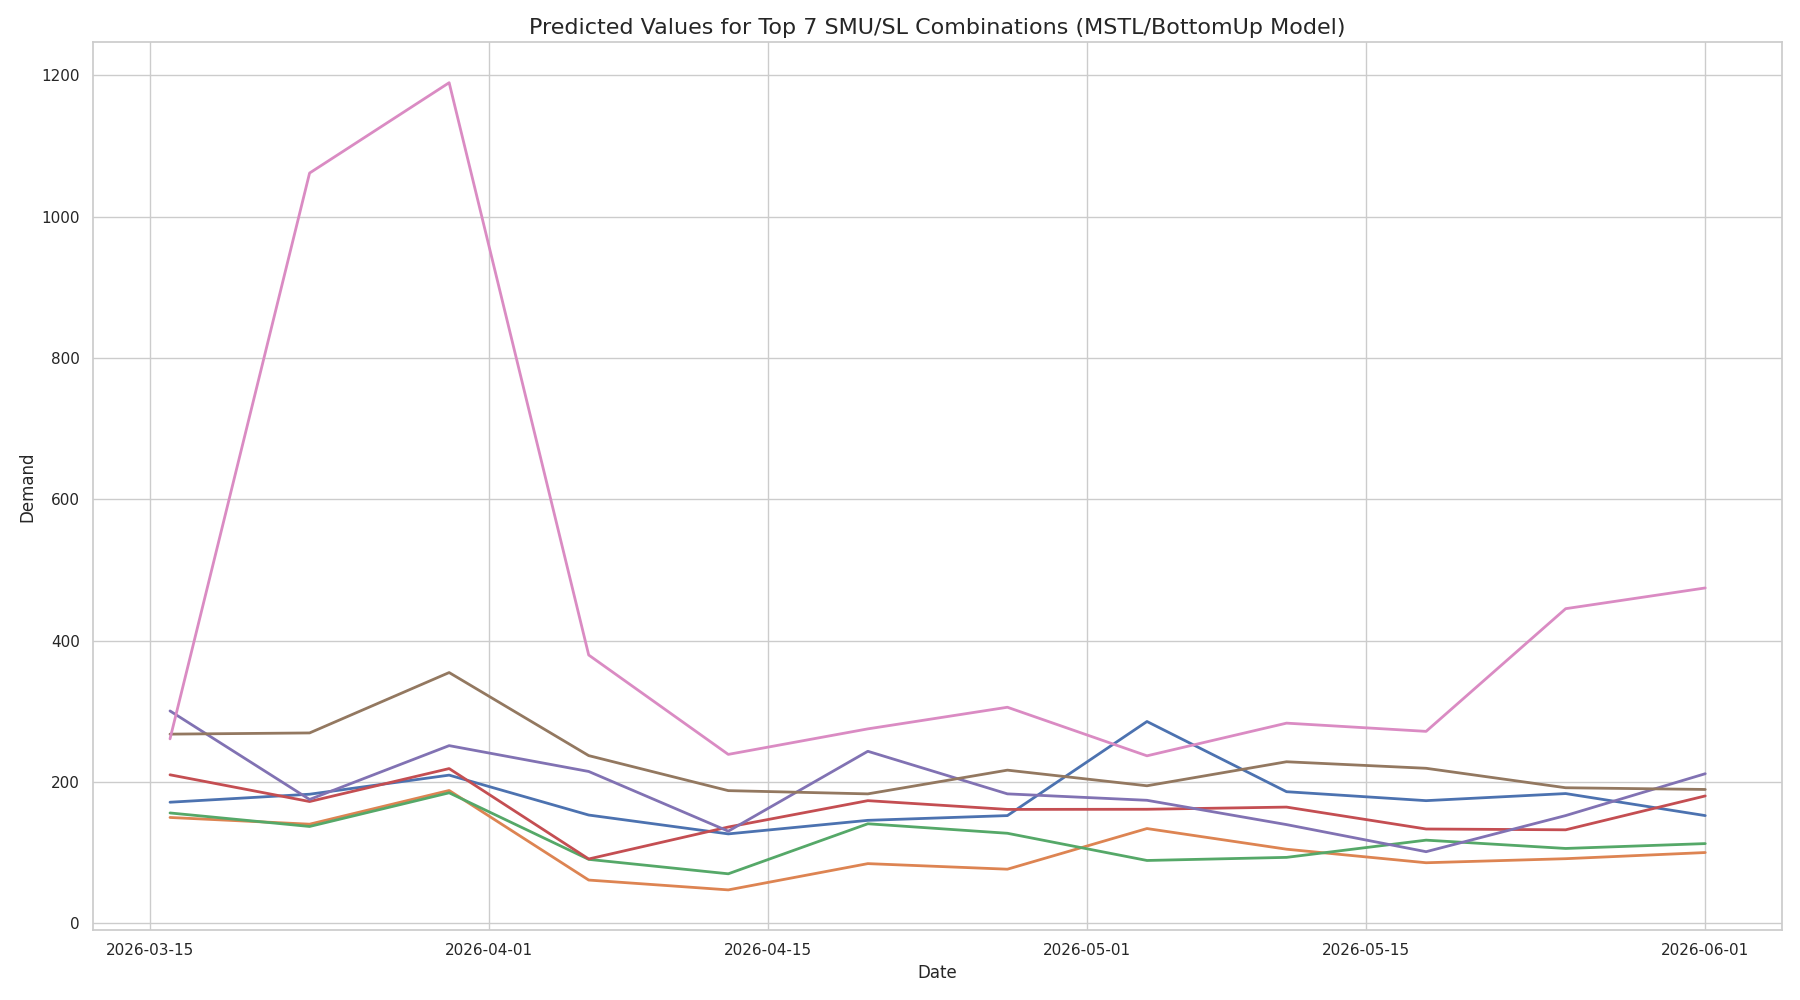


--- Top 7 SMU/SL unique_ids ---
Overall/SMU-3/SL-2
Overall/SMU-4/SL-4
Overall/SMU-2/SL-2
Overall/SMU-1/SL-4
Overall/SMU-2/SL-1
Overall/SMU-1/SL-2
Overall/SMU-2/SL-4


In [52]:
print("### Predicted Values for Top 7 SMU/SL Combinations")
display(Image('smu_sl_top7_predicted_values.png'))

print("\n--- Top 7 SMU/SL unique_ids ---")
for s_id in top7_smu_sl_ids:
    print(s_id)

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter for 'SMU/SL/Sector' level data
smu_sl_sector_level_df = eval_df_mstl[eval_df_mstl['hierarchy_level'] == 'SMU/SL/Sector'].copy()

# 2. Identify the top 7 SMU/SL/Sector combinations based on total actual demand ('y')
top7_smu_sl_sector_ids = smu_sl_sector_level_df.groupby('unique_id')['y'].sum().nlargest(7).index.tolist()

# 3. Filter the DataFrame to include only these top 7 SMU/SL/Sector combinations
smu_sl_sector_top7_df = smu_sl_sector_level_df[smu_sl_sector_level_df['unique_id'].isin(top7_smu_sl_sector_ids)].copy()

# 4. Melt the DataFrame to prepare for plotting predicted values only
smu_sl_sector_top7_melted = smu_sl_sector_top7_df.melt(
    id_vars=['unique_id', 'ds'],
    value_vars=['MSTL/BottomUp'], # Only include predicted values
    var_name='Type',
    value_name='Demand'
)

# Rename 'MSTL/BottomUp' to 'Predicted'
smu_sl_sector_top7_melted['Type'] = smu_sl_sector_top7_melted['Type'].replace({'MSTL/BottomUp': 'Predicted'})

# Sort by date for proper time series plotting
smu_sl_sector_top7_melted = smu_sl_sector_top7_melted.sort_values(by=['unique_id', 'ds', 'Type'])

# 5. Create the line plot
plt.figure(figsize=(18, 10)) # Adjust figure size for better readability
sns.lineplot(
    data=smu_sl_sector_top7_melted,
    x='ds',
    y='Demand',
    hue='unique_id',      # Differentiate SMU/SL/Sector by color
    linewidth=2,
    markers=False,
    legend=True            # Explicitly ensure legend is displayed
)

plt.title('Predicted Values for Top 7 SMU/SL/Sector Combinations (MSTL/BottomUp Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.grid(True)
plt.tight_layout()

# Place the legend outside the plot area for better readability
plt.legend(title='SMU/SL/Sector', bbox_to_anchor=(1.05, 1), loc='upper left') # Updated legend title

# 6. Save the plot
filename = "smu_sl_sector_top7_predicted_values.png"
plt.savefig(filename)
plt.close()

print(f"Plot saved successfully as '{filename}'")

Plot saved successfully as 'smu_sl_sector_top7_predicted_values.png'


In [54]:
print("--- Top 7 SMU/SL/Sector unique_ids ---")
for s_id in unique_smu_sl_sector_ids:
    print(s_id)

--- Top 7 SMU/SL/Sector unique_ids ---
Overall/SMU-1/SL-1/Sector-01
Overall/SMU-1/SL-1/Sector-04
Overall/SMU-1/SL-1/Sector-10
Overall/SMU-1/SL-1/Sector-12
Overall/SMU-1/SL-1/Sector-13
Overall/SMU-1/SL-1/Sector-19
Overall/SMU-1/SL-1/Sector-20
Overall/SMU-1/SL-2/Sector-01
Overall/SMU-1/SL-2/Sector-04
Overall/SMU-1/SL-2/Sector-10
Overall/SMU-1/SL-2/Sector-12
Overall/SMU-1/SL-2/Sector-13
Overall/SMU-1/SL-2/Sector-19
Overall/SMU-1/SL-3/Sector-01
Overall/SMU-1/SL-3/Sector-04
Overall/SMU-1/SL-3/Sector-10
Overall/SMU-1/SL-3/Sector-12
Overall/SMU-1/SL-3/Sector-13
Overall/SMU-1/SL-3/Sector-19
Overall/SMU-1/SL-3/Sector-20
Overall/SMU-1/SL-4/Sector-01
Overall/SMU-1/SL-4/Sector-04
Overall/SMU-1/SL-4/Sector-10
Overall/SMU-1/SL-4/Sector-12
Overall/SMU-1/SL-4/Sector-13
Overall/SMU-1/SL-4/Sector-19
Overall/SMU-1/SL-4/Sector-20
Overall/SMU-1/SL-5/Sector-01
Overall/SMU-1/SL-5/Sector-04
Overall/SMU-1/SL-5/Sector-10
Overall/SMU-1/SL-5/Sector-12
Overall/SMU-1/SL-5/Sector-13
Overall/SMU-1/SL-5/Sector-19
Over

**Reasoning**:
I need to add the Chart.js visualizations to the `streamlit_app.py` file. This involves embedding the HTML and JavaScript code directly into the Streamlit app using `st.components.v1.html`.



## Provide Run Instructions

### Subtask:
Provide instructions on how to save the `streamlit_app.py` file and run the Streamlit application locally, allowing you to view and interact with the dashboard.


### How to Run the Streamlit Application Locally

To view the interactive dashboard:

1.  **Save the `streamlit_app.py` file:** The `streamlit_app.py` file has been generated in your Colab environment. You will need to download this file to your local machine. You can do this by navigating to the file browser in Colab (usually on the left sidebar), right-clicking on `streamlit_app.py`, and selecting 'Download'.

2.  **Install Streamlit (if you haven't already):** Open your local terminal or command prompt and run the following command:
    ```bash
    pip install streamlit
    ```

3.  **Navigate to the directory:** In your terminal, change the current directory to where you saved `streamlit_app.py`.
    ```bash
    cd /path/to/your/downloaded/file
    ```

4.  **Run the Streamlit application:** Execute the following command in your terminal:
    ```bash
    streamlit run streamlit_app.py
    ```

5.  **View the Dashboard:** After running the command, Streamlit will open a new tab in your default web browser displaying the dashboard. If it doesn't open automatically, it will provide a local URL (e.g., `http://localhost:8501`) that you can copy and paste into your browser.

## Display Key Performance Indicators (KPIs)

### Subtask:
Add code to `streamlit_app.py` to display the calculated MAE, RMSE, WMAPE, and Min/Max Ratio using Streamlit's `st.metric` component, providing a clear overview of the model's performance at the 'Total' level.


## Create Chart.js Visualizations in Streamlit

### Subtask:
Embed the three Chart.js visualizations (Actual vs. Predicted, Residual Distribution, and Residuals Over Time) within the Streamlit application.


**Reasoning**:
The subtask instructs to add the `st.components.v1` import and embed the Chart.js visualizations. The previous `%%writefile` block already handled the embedding and dynamic HTML generation for the charts. This step will modify the `streamlit_app.py` file to include the explicit import for `streamlit.components.v1` as `components` at the top, and update the usage from `st.components.v1.html` to `components.html`.



In [55]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- 1. PAGE CONFIGURATION ---
st.set_page_config(
    page_title="Resource Forecasting Dashboard",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# --- 2. DATA & IMAGE PATHS ---
# This dashboard_data is for the Streamlit app. It includes hardcoded values
# from the most recent evaluation in the Colab notebook.
dashboard_data = {
    "dates": ['2026-03-16', '2026-03-23', '2026-03-30', '2026-04-06', '2026-04-13', '2026-04-20', '2026-04-27', '2026-05-04', '2026-05-11', '2026-05-18', '2026-05-25', '2026-06-01'],
    "actuals": [3120, 3105, 3873, 3593, 2589, 2257, 2443, 2537, 2569, 2910, 2922, 2204],
    "preds": [2973.58, 3872.29, 4879.65, 2736.65, 2180.57, 2668.04, 2601.82, 2803.39, 2625.32, 2647.73, 2716.03, 2815.33],
    "residuals": [146.41, -767.29, -1006.65, 856.34, 408.42, -411.04, -158.82, -266.39, -56.32, 262.26, 205.96, -611.33],
    "metrics": {"mae": 429.77, "rmse": 522.57, "wmape": 15.11, "min_max_ratio": 0.8703},
    "metrics_by_level": {
        "Total": {"mae": 429.77, "rmse": 522.57, "wmape": 15.11},
        "SMU": {"mae": 161.04, "rmse": 235.45, "wmape": 22.65},
        "SMU/SL": {"mae": 37.77, "rmse": 72.90, "wmape": 37.19},
        "SMU/SL/Sector": {"mae": 12.64, "rmse": 32.72, "wmape": 54.03},
    },
    "hierarchy_info": { # NEW: Added hierarchy image paths and unique IDs
        "Total": {"image_path": "", "unique_ids": []},
        "SMU": {"image_path": "/content/smu_all_predicted_values.png", "unique_ids": ['Overall/SMU-1', 'Overall/SMU-2', 'Overall/SMU-3', 'Overall/SMU-4']},
        "SMU/SL": {"image_path": "/content/smu_sl_top7_predicted_values.png", "unique_ids": ['Overall/SMU-3/SL-2', 'Overall/SMU-4/SL-4', 'Overall/SMU-2/SL-2', 'Overall/SMU-1/SL-4', 'Overall/SMU-2/SL-1', 'Overall/SMU-1/SL-2', 'Overall/SMU-2/SL-4']},
        "SMU/SL/Sector": {"image_path": "/content/smu_sl_sector_top7_predicted_values.png", "unique_ids": ['Overall/SMU-4/SL-4/Sector-15', 'Overall/SMU-3/SL-2/Sector-09', 'Overall/SMU-2/SL-2/Sector-03', 'Overall/SMU-3/SL-7/Sector-09', 'Overall/SMU-1/SL-4/Sector-01', 'Overall/SMU-1/SL-3/Sector-13', 'Overall/SMU-2/SL-4/Sector-03']}
    }
}

# Convert time series data to a Pandas DataFrame for easy plotting
df = pd.DataFrame({
    'Date': pd.to_datetime(dashboard_data['dates']),
    'Actual': dashboard_data['actuals'],
    'Predicted': dashboard_data['preds'],
    'Residual': dashboard_data['residuals']
})

# Add a color column for the residual bars (Green for positive, Red for negative)
df['Residual_Color'] = df['Residual'].apply(lambda x: '#34a853' if x >= 0 else '#ea4335')


# --- 3. SIDEBAR ---
with st.sidebar:
    st.image("https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Wipro_Primary_Logo_Color_RGB.svg/330px-Wipro_Primary_Logo_Color_RGB.svg.png", width=150)
    st.title("Navigation")
    st.markdown("Use the tabs in the main window to explore the dashboard.")
    st.markdown("---")
    st.markdown("**Model Info:**")
    st.info("MSTL / BottomUp Model\n\nForecasting workforce demand to prevent resource shortages and optimize utilization.")


# --- 4. MAIN DASHBOARD ---
st.title("📊 Resource Forecasting Dashboard")
st.markdown("Track and analyze workforce demand predictions across organizational hierarchies.")

# Top-level KPIs
st.subheader("Total Level Performance")
kpi_col1, kpi_col2, kpi_col3, kpi_col4 = st.columns(4)
kpi_col1.metric("MAE (Mean Absolute Error)", dashboard_data["metrics"]["mae"])
kpi_col2.metric("RMSE", dashboard_data["metrics"]["rmse"])
kpi_col3.metric("WMAPE", f"{dashboard_data['metrics']['wmape']}% ")
kpi_col4.metric("Min/Max Ratio", dashboard_data["metrics"]["min_max_ratio"])

st.markdown("---")

# --- 5. TABS LAYOUT ---
tab1, tab2, tab3 = st.tabs(["📈 Main Analytics", "🏢 Hierarchy Deep-Dive", "📝 Project Context"])

# ----------------- TAB 1: MAIN ANALYTICS (PLOTLY CHARTS) -----------------
with tab1:
    # Row 1: Actual vs Predicted
    st.subheader("Actual vs Predicted Demand")
    fig_line = go.Figure()
    fig_line.add_trace(go.Scatter(x=df['Date'], y=df['Actual'], mode='lines+markers', name='Actual', line=dict(color='#1a73e8', width=3)))
    fig_line.add_trace(go.Scatter(x=df['Date'], y=df['Predicted'], mode='lines+markers', name='Predicted', line=dict(color='#34a853', width=3, dash='dash')))
    fig_line.update_layout(height=400, margin=dict(l=0, r=0, t=30, b=0), hovermode="x unified")
    st.plotly_chart(fig_line, use_container_width=True)

    # Row 2: Residuals
    col_chart1, col_chart2 = st.columns(2)

    with col_chart1:
        st.subheader("Residuals Over Time")
        fig_bar = go.Figure()
        fig_bar.add_trace(go.Bar(
            x=df['Date'],
            y=df['Residual'],
            marker_color=df['Residual_Color'],
            name='Residual (Act - Pred)'
        ))
        fig_bar.update_layout(height=350, margin=dict(l=0, r=0, t=30, b=0))
        st.plotly_chart(fig_bar, use_container_width=True)

    with col_chart2:
        st.subheader("Residual Distribution")
        fig_hist = px.histogram(df, x="Residual", nbins=8, color_discrete_sequence=['#8e24aa'])
        fig_hist.update_layout(height=350, margin=dict(l=0, r=0, t=30, b=0), showlegend=False)
        st.plotly_chart(fig_hist, use_container_width=True)

# ----------------- TAB 2: HIERARCHY DEEP-DIVE -----------------
with tab2:
    st.subheader("Accuracy by Hierarchy Level")

    # Dynamic selection instead of long expanders
    selected_level = st.selectbox("Select Hierarchy Level to view:", list(dashboard_data["metrics_by_level"].keys()))

    metrics = dashboard_data["metrics_by_level"][selected_level]

    st.markdown(f"#### Metrics for {selected_level}")
    lvl_col1, lvl_col2, lvl_col3 = st.columns(3)
    lvl_col1.metric("MAE", metrics["mae"])
    lvl_col2.metric("RMSE", metrics["rmse"])
    lvl_col3.metric("WMAPE", f"{metrics['wmape']}% ")

    # Access hierarchy_info from dashboard_data
    selected_level_info = dashboard_data["hierarchy_info"].get(selected_level, {})
    img_path = selected_level_info.get("image_path", "")
    level_unique_ids = selected_level_info.get("unique_ids", []) # Get unique_ids for the selected level

    if img_path:
        st.markdown("---")
        try:
            st.image(img_path, caption=f"Actual vs Predicted - {selected_level}", use_column_width=True)
            if level_unique_ids: # Display unique IDs if available
                st.markdown(f"**Unique IDs for {selected_level}:**")
                for uid in level_unique_ids:
                    st.write(f"- {uid}")
        except Exception:
            st.error(f"Could not load image. Please double-check the path: `{img_path}`")
    elif selected_level != "Total":
        st.info(f"No image path provided for {selected_level}. Add the path to the `hierarchy_info` dictionary in the code.")
        if level_unique_ids: # Display unique IDs even if no image is found (but only if not 'Total')
            st.markdown(f"**Unique IDs for {selected_level}:**")
            for uid in level_unique_ids:
                st.write(f"- {uid}")

# ----------------- TAB 3: PROJECT CONTEXT -----------------
with tab3:
    st.subheader("Business Objective")
    st.write("""
    Business demand for resources varies across different organizational units and over time,
    making it difficult to accurately estimate future resource requirements. Manual forecasting
    methods and reactive planning often lead to resource shortages, excess allocation, project delays,
    and inefficient utilization, while maintaining consistency in demand estimates across organizational
    hierarchies remains a persistent challenge.

    **Objective:** The goal of this initiative is to address this gap by developing a data-driven forecasting
    solution for workforce demand prediction, using statistical time series models to support more accurate
    and effective resource planning.
    """)

Writing streamlit_app.py


## Install localtunnel

### Subtask:
Install the `localtunnel` package which will be used to create a public URL for the Streamlit application.


**Reasoning**:
I need to install localtunnel globally using npm, as it's a Node.js package and not available via pip.



In [56]:
!!! Installing Node.js and npm is required for localtunnel !!!
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

# Task
Develop a Streamlit application that visualizes the validation results of the MSTL/BottomUp model at the 'Total' hierarchy level. The dashboard should display key performance indicators (MAE, RMSE, WMAPE, Min/Max Ratio) and three interactive Chart.js visualizations: Actual vs. Predicted, Residual Distribution, and Residuals Over Time. Provide instructions on how to run the Streamlit app locally.

**Reasoning**:
I need to correctly install `localtunnel` using `npm` by removing the erroneous informational line from the previous attempt.



In [57]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦
changed 22 packages in 837ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

### Use `ngrok` instead of `localtunnel`

First, let's install `ngrok` if it's not already available. Even though `localtunnel` was installed via `npm`, `ngrok` has a convenient Python wrapper.

In [58]:
# Install ngrok for Colab
!pip install ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 20.7 MB/s eta 0:00:00


In [59]:
# Install Streamlit if not already installed
!pip install streamlit > /dev/null

# Install pyngrok if not already installed
!pip install pyngrok > /dev/null

In [60]:
import sys
import subprocess
import os
from pyngrok import ngrok, conf
from google.colab import userdata
import time



# Kill any processes running on port 8501 (Streamlit's default port) if they exist
!kill $(lsof -t -i:8501)

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get the ngrok authentication token from Colab secrets
try:
    auth_token = userdata.get("NGROK_AUTH_TOKEN")
    if auth_token is None:
        raise ValueError("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")
    conf.get_default().auth_token = auth_token
    print("ngrok authenticated successfully.")
except Exception as e:
    print(f"Error authenticating ngrok: {e}")
    print("Please ensure 'NGROK_AUTH_TOKEN' is added to Colab's 'Secrets' tab (under the key 'NGROK_AUTH_TOKEN').")
    sys.exit(1) # Exit if authentication fails

# Ensure the log file is empty or created for Streamlit output
with open('/content/streamlit_logs.txt', 'w') as f:
    f.write('')

# Start Streamlit application in the background on port 8501
# Use preexec_fn=os.setsid to create a new process group for easier killing later
print("Starting Streamlit app in the background...")
streamlit_process = subprocess.Popen(
    ['python', '-m', 'streamlit', 'run', 'streamlit_app.py', '--server.port', '8501', '--server.enableCORS', 'true', '--server.enableXsrfProtection', 'false'],
    stdout=open('/content/streamlit_logs.txt', 'a'), # Redirect stdout to log file
    stderr=open('/content/streamlit_logs.txt', 'a'), # Redirect stderr to log file
    preexec_fn=os.setsid # Detach from current process group
)

print(f"Streamlit app started (PID: {streamlit_process.pid}). Logs can be found in /content/streamlit_logs.txt")

# Give Streamlit some time to start up (adjust if needed)
time.sleep(10)

# Create an ngrok tunnel to the Streamlit app port (8501)
try:
    public_url = ngrok.connect(8501).public_url
    print(f"\nYour Streamlit app is now publicly accessible at: {public_url}")
    print("Click the link above to open your dashboard.")
except Exception as e:
    print(f"Failed to create ngrok tunnel: {e}")
    print("Please check the Streamlit logs for errors: /content/streamlit_logs.txt")
    print("Also, ensure your NGROK_AUTH_TOKEN is correct and Streamlit started successfully.")

kill: usage: kill [-s sigspec | -n signum | -sigspec] pid | jobspec ... or kill -l [sigspec]
ngrok authenticated successfully.
Starting Streamlit app in the background...
Streamlit app started (PID: 24454). Logs can be found in /content/streamlit_logs.txt

Your Streamlit app is now publicly accessible at: https://superhero-lapel-grandly.ngrok-free.dev
Click the link above to open your dashboard.
